In [ ]:
#A Cheminformatics-Based Exploration of Pathway-Linked Eye Biomarkers from the EBD Database

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns

packages = {
    "Python": sys.version.split()[0],
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
    "seaborn": sns.__version__
}

for pkg, ver in packages.items():
    print(f"{pkg}: {ver}")


Python: 3.12.12
pandas: 2.2.2
numpy: 2.0.2
matplotlib: 3.10.0
seaborn: 0.13.2


In [32]:
import pandas as pd
file = "EBD.xlsx"
df = pd.read_excel(file, sheet_name="Biomarkers for eye diseases")
# ---------------------------------------------------
# 1) Hastalık bazlı analiz: hangi hastalık için kaç biomarker var?
disease_counts = df['disease'].value_counts()
print("\n🔹 Hastalık Bazlı Biomarker Dağılımı:\n", disease_counts)

# ---------------------------------------------------
# 2) Gen bazlı analiz: hangi gen kaç hastalıkla ilişkili?
gene_disease = df.groupby('Officialsymbol')['disease'].unique()
print("\n🔹 Genlerin ilişkili olduğu hastalıklar:\n", gene_disease)

# ---------------------------------------------------
# 3) Popülasyon bazlı analiz
population_counts = df['Race'].value_counts()
print("\n🔹 Popülasyon dağılımı:\n", population_counts)

# Aynı gen farklı popülasyonlarda tekrar ediyor mu?
gene_population = df.groupby('Officialsymbol')['Race'].unique()
print("\n🔹 Genlerin çalışıldığı popülasyonlar:\n", gene_population)

# ---------------------------------------------------
# 4) İstatistiksel güvenilirlik
# (Confidence ve IF gibi metrikleri inceleme)
confidence_summary = df['Confidence'].value_counts().sort_index(ascending=False)
print("\n🔹 Confidence dağılımı:\n", confidence_summary)




🔹 Hastalık Bazlı Biomarker Dağılımı:
 disease
diabetic retinopathy (DR)                                        224
age related macular degeneration (AMD)                           217
glaucoma                                                         192
primary open angle glaucoma (POAG)                               105
diabetic macular edema (DME)                                      55
                                                                ... 
non-arteritic anterior ischemic optic neuropathy (NAION)           1
ocular hypotony                                                    1
vogt-koyanagi-harada (VKH) disease                                 1
recalcitrant juvenile idiopathic arthritis-associated uveitis      1
inflammation and DED in POAG                                       1
Name: count, Length: 169, dtype: int64

🔹 Genlerin ilişkili olduğu hastalıklar:
 Officialsymbol
3 alpha-HSD                                                          [glaucoma]
8-iso-prostaglandi

In [18]:
len(df)

1197

In [7]:
# 2. İlk satırlara göz at
df.head()

,BID,Biomarker,disease,url,Category4,Discription,Region,Race,Number,Gender,...,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Confidence
0,3,VIPR2,high myopia,https://pubmed.ncbi.nlm.nih.gov/23637909/,Nucleic Acids-Based Biomarker,"JUN (Jun Proto-Oncogene, AP-1 Transcription Fa...","Hongkong, China, Asia",Asian,1200,690/858,...,Yes,Yes,Yes,Yes,Can't tell,Yes,Yes,Can't tell,Can't tell,8/11
1,4,vasoactive intestinal peptide receptor 2 (VIPR2),refractive error,https://pubmed.ncbi.nlm.nih.gov/23637909/,Nucleic Acids-Based Biomarker,VIPR2 is one of the VIP receptors and is locat...,"Hongkong, China, Asia",Asian,1200,690/858,...,Yes,Yes,Yes,Yes,Can't tell,Yes,Yes,Can't tell,Can't tell,8/11
2,5,FXIII-A 185-T-Allele,age related macular degeneration (AMD),https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4...,Nucleic Acids-Based Biomarker,factorXIII-Agene(FXIII-A-G185T;rs5985)hasbeend...,NaN,American,412,190/222,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,11/11
3,6,FXIII-A 185-T-Allele,pathologic myopia (PM),https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4...,Nucleic Acids-Based Biomarker,factorXIII-Agene(FXIII-A-G185T;rs5985)hasbeend...,NaN,American,412,190/222,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,11/11
4,7,rs10033900,age related macular degeneration (AMD),https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,Nucleic Acids-Based Biomarker,The T allele of rs10033900 is reported to be a...,"France, Europe; America",European,267,19/52,...,Yes,Yes,Yes,Yes,Can't tell,Yes,Yes,Yes,Yes,10/11


In [33]:
df['disease'] = (
    df['disease']
    .str.lower()                      # küçük harf
    .str.replace('-', ' ', regex=False)  # tire → boşluk
    .str.replace(r'\s+', ' ', regex=True) # fazla boşlukları sil
    .str.strip())

In [34]:
del df['BID']

In [10]:
""""
df['Biomarker'] = (
    df['Biomarker']
    .str.strip()
    .str.replace('miRNA-', 'miR-', regex=False)
    .str.replace('miRNA', 'miR', regex=False))

In [48]:
df['Biomarker'] = (
    df['Biomarker']
    .str.strip()
    .str.replace('miR-', 'miRNA-', regex=False)
    .str.replace('plasma', '', regex=False)
    .str.replace('hsa-mi','mi', regex=False))

In [49]:
len(df['Biomarker'].unique())

889

In [50]:
# “mir yazısı” ifadesi geçen satırları filtrele
df2 =  df[df['Biomarker'].str.contains('miR', na=True)]
# index’i resetle
df2 = df2.reset_index(drop=True)

In [51]:
len(df2)

42

In [44]:
df2.head()

,Biomarker,disease,url,Category4,Discription,Region,Race,Number,Gender,Age,...,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Confidence,Confidence_num
0,miRNA-126,diabetic retinopathy (dr),https://pubmed.ncbi.nlm.nih.gov/27696070/,Nucleic Acids-Based Biomarker,"MicroRNAs (miRNAs) are small, nonprotein-encod...",Europe,European,3250,NaN,NaN,...,Yes,Yes,Yes,Can't tell,Yes,Yes,Yes,Yes,10/11,10.0
1,miRNA-15a,cataract,https://pubmed.ncbi.nlm.nih.gov/31264507/,Nucleic Acids-Based Biomarker,this miRNA with the expression of its target a...,"Egypt, Africa",African,160,84/66,58.8±2.9; 57.9±1.2,...,Yes,Can't tell,Yes,Can't tell,Yes,Yes,Can't tell,Yes,8/11,8.0
2,miRNA-126,diabetic retinopathy (dr),https://pubmed.ncbi.nlm.nih.gov/27696070/,Nucleic Acids-Based Biomarker,"MicroRNAs (miRNAs) are small, nonprotein-encod...",Europe,European,3250,NaN,NaN,...,Yes,Yes,Yes,Can't tell,Yes,Yes,Yes,Yes,10/11,10.0
3,miRNA-377-3p,age related macular degeneration (amd),https://pubmed.ncbi.nlm.nih.gov/33906524/,Nucleic Acids-Based Biomarker,"hus far, the role of serum exosomal microRNAs ...",NaN,NaN,44,NaN,NaN,...,Yes,No,Yes,Yes,Yes,Yes,Can't tell,Yes,9/11,9.0
4,miRNA-410,age related macular degeneration (amd),https://pubmed.ncbi.nlm.nih.gov/32818115/,Nucleic Acids-Based Biomarker,MicroRNAs (miRNAs) are small noncoding RNAs th...,Ireland,NaN,377,NaN,NaN,...,Yes,Yes,Yes,Yes,Can't tell,Can't tell,Yes,Yes,9/11,9.0


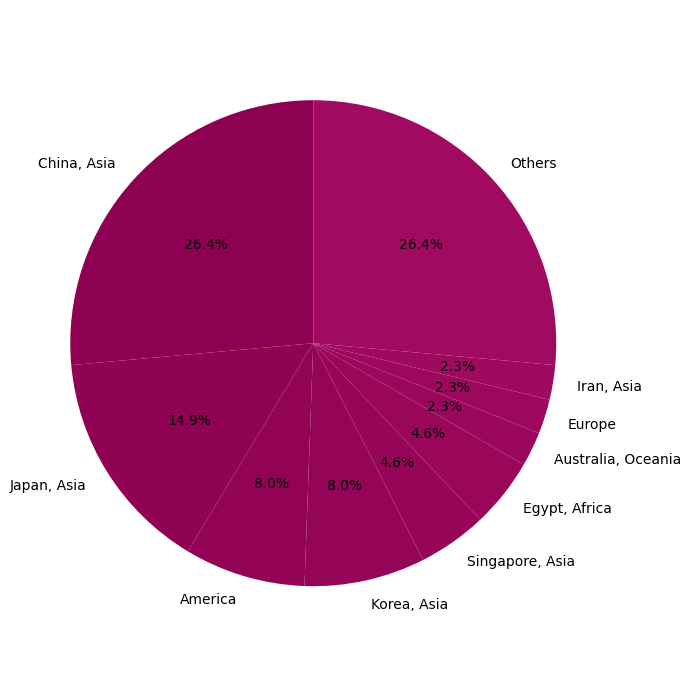

In [45]:
import matplotlib #pip install matplotlib
import matplotlib.pyplot as plt
# Diabetic Retinopathy (DR) satırlarını filtrele
df_dr = df[df['disease'].str.lower() == 'diabetic retinopathy (dr)'].copy()
# Beijing'i China altına topla
df_dr['Region'] = df_dr['Region'].replace('Beijing, China, Asia', 'China, Asia')
# Region bazlı sayım
region_counts = df_dr['Region'].value_counts()
# Yüzdelik hesapla
region_percent = 100 * region_counts / region_counts.sum()
# 2%'den küçükleri Others olarak birleştir
region_counts_mod = region_counts.copy()
small_regions = region_percent[region_percent < 2].index
if len(small_regions) > 0:
    others_sum = region_counts_mod[small_regions].sum()
    region_counts_mod = region_counts_mod.drop(small_regions)
    region_counts_mod['Others'] = others_sum
# Pie chart
plt.figure(figsize=(7,7))
plt.pie(
    region_counts_mod,
    labels=region_counts_mod.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.PiYG(range(len(region_counts_mod))))
#plt.title('Diabetic Retinopathy (DR) Studies by Region', fontsize=11, fontweight='bold')
plt.axis('equal')  # Daireyi düzgün yapmak için
plt.tight_layout()
plt.savefig('Fig2.png', dpi=300, format='png', bbox_inches='tight')
plt.show()


En Yüksek Confidence Olan Disease'ler:
                               disease Confidence                  Region  \
8   primary open angle glaucoma (poag)      11/11  Guangdong, China, Asia   
0            diabetic retinopathy (dr)      10/11                  Europe   
9                             glaucoma      10/11                     NaN   
2            diabetic retinopathy (dr)      10/11                  Europe   
7            diabetic retinopathy (dr)      10/11             China, Asia   
5            diabetic retinopathy (dr)      10/11             China, Asia   
13                            glaucoma      10/11                     NaN   
12                            glaucoma      10/11                     NaN   

    Number  
8       68  
0     3250  
9       64  
2     3250  
7      120  
5      304  
13      64  
12      64  

Bölgelere Göre Dağılım:
Region
Europe                    2
Egypt, Africa             2
Ireland                   2
China, Asia               2
Guang

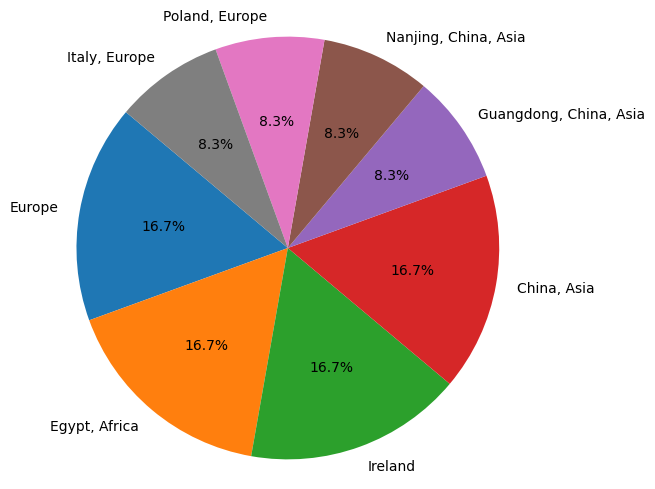

In [41]:
# Confidence'ı sayısala çevir
df2['Confidence_num'] = df2['Confidence'].str.split('/').str[0].astype(float)
# En yüksek confidence'a sahip Disease'ler
top_conf = df2.sort_values('Confidence_num', ascending=False).head(8)
print("\nEn Yüksek Confidence Olan Disease'ler:")
print(top_conf[['disease', 'Confidence', 'Region', 'Number']])
# Bölgelere göre dağılım (aynı kalıyor)
region_counts = df2['Region'].value_counts()
print("\nBölgelere Göre Dağılım:")
print(region_counts)
# Pie chart visualization
plt.figure(figsize=(6, 6))
plt.pie(
    region_counts,
    labels=region_counts.index,
    autopct='%1.01f%%',
    startangle=140)
plt.axis('equal')
plt.savefig('Fig2.png', dpi=300, format='png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_694/931835352.py:12: UserWarning: Glyph 12289 (\N{IDEOGRAPHIC COMMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()  # Adjust layout to make room for labels
/tmp/ipykernel_694/931835352.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()  # Adjust layout to make room for labels
/tmp/ipykernel_694/931835352.py:13: UserWarning: Glyph 12289 (\N{IDEOGRAPHIC COMMA}) missing from font(s) DejaVu Sans.
  plt.savefig('Fig4.png', dpi=300, format='png', bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12289 (\N{IDEOGRAPHIC COMMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


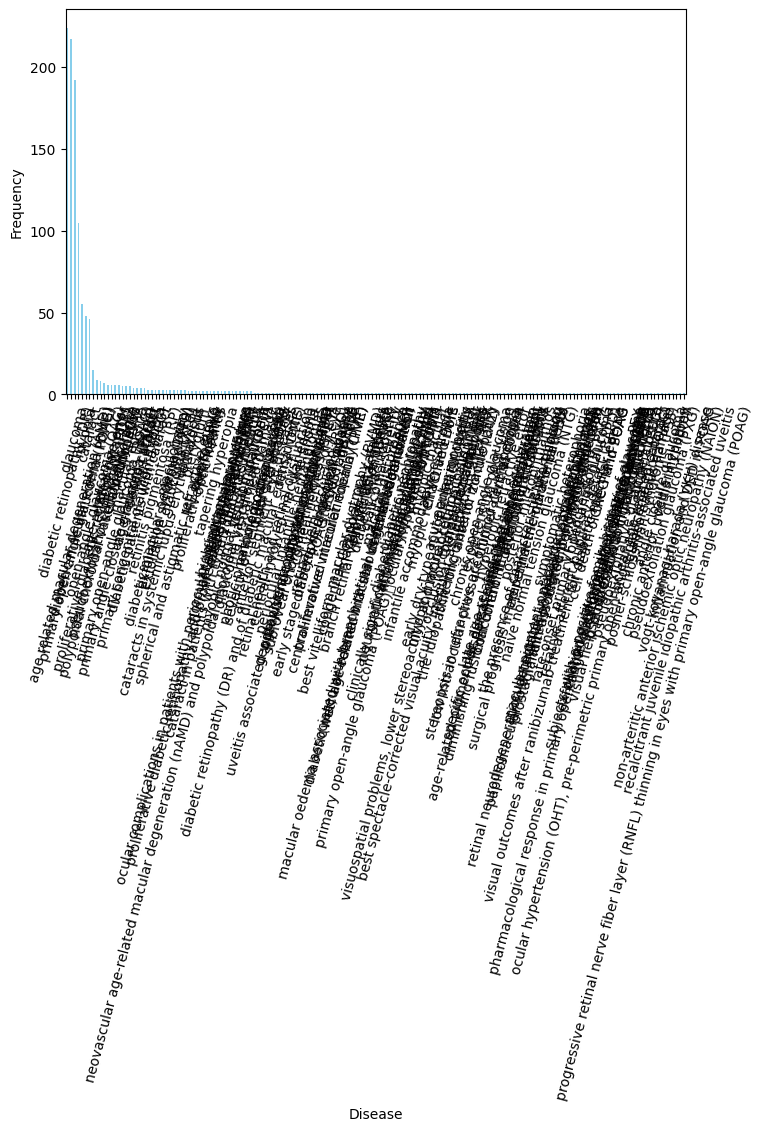

In [66]:
import matplotlib.pyplot as plt
# Count the occurrences of each disease
disease_counts1 = df2['disease'].value_counts()
# Create a bar plot
plt.figure(figsize=(8, 5))
disease_counts.plot(kind='bar', color='skyblue')
#plt.title('Diseases Studied in Dataset')
plt.xlabel('Disease')
plt.ylabel('Frequency')
plt.xticks(rotation=75)
plt.grid(False)
plt.tight_layout()  # Adjust layout to make room for labels
plt.savefig('Fig4.png', dpi=300, format='png', bbox_inches='tight')
plt.show()


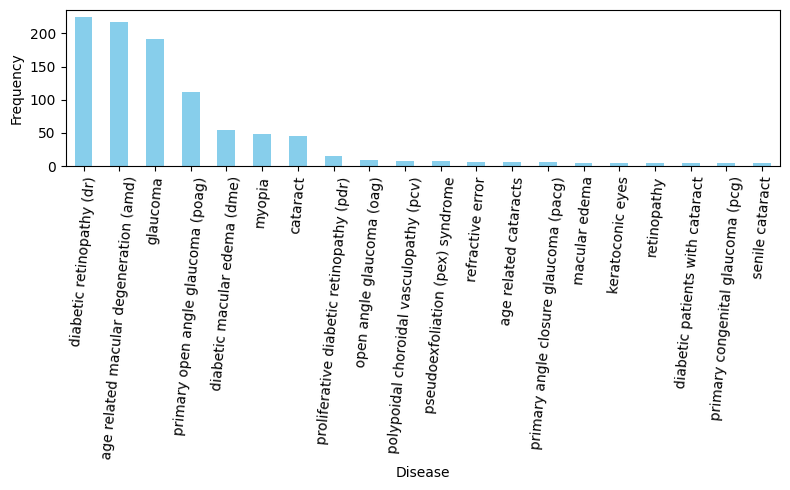

In [67]:
# Count the occurrences of each disease and take top 20
disease_counts = df['disease'].value_counts().head(20)
# Create a bar plot
plt.figure(figsize=(8, 5))
disease_counts.plot(kind='bar', color='skyblue')

plt.xlabel('Disease')
plt.ylabel('Frequency')
plt.xticks(rotation=85)
plt.grid(False)
plt.tight_layout()  # Adjust layout to make room for labels
plt.savefig('Fig4.png', dpi=300, format='png', bbox_inches='tight')
plt.show()


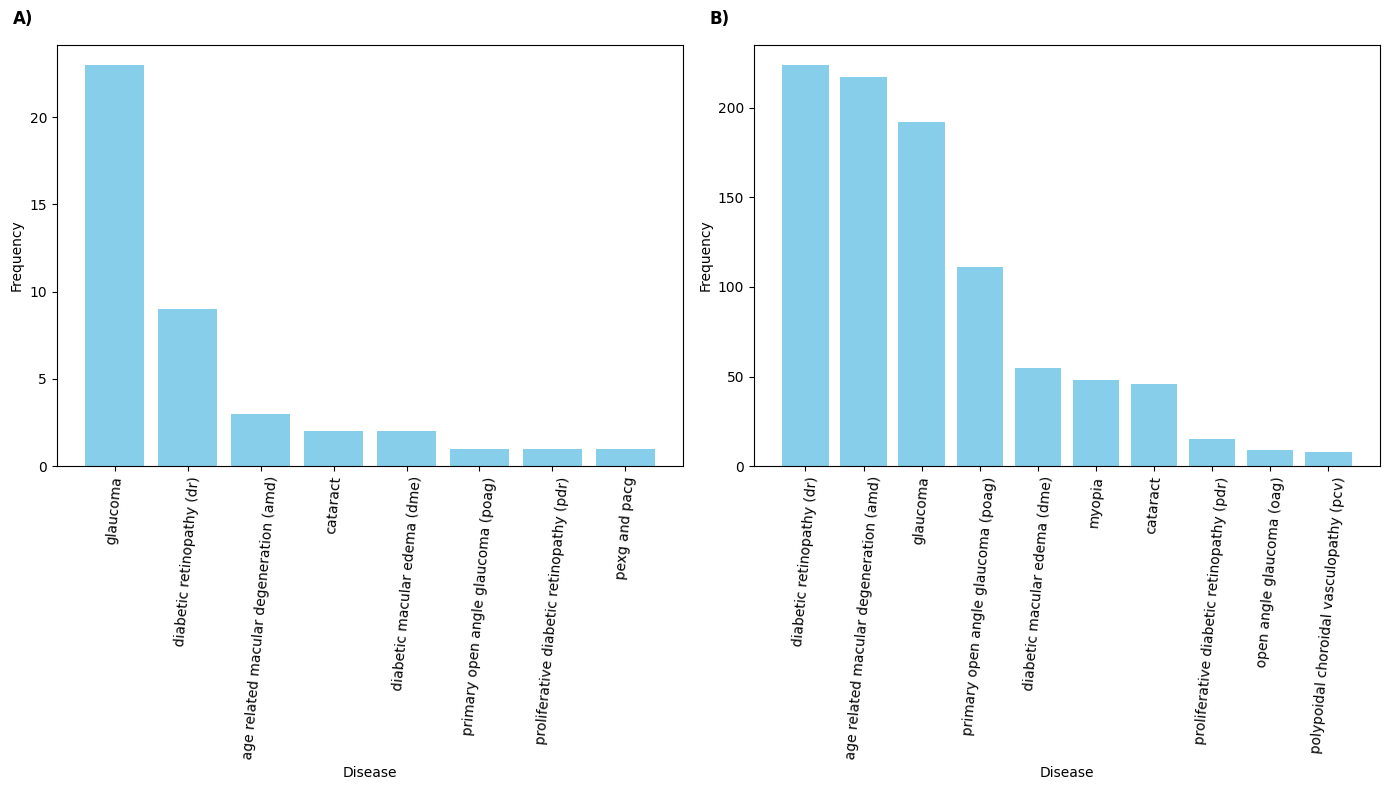

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
fig.subplots_adjust(wspace=0.3)

# -----------------------------
# A) Top Diseases
# -----------------------------
disease_counts = df2['disease'].value_counts().head(10)
disease_counts1 = df['disease'].value_counts().head(10)
axes[0].bar(disease_counts.index, disease_counts.values, color='skyblue')
axes[0].set_xlabel('Disease')
axes[0].set_ylabel('Frequency')
axes[0].set_title('A)', loc='left', fontweight='bold', pad=15,x=-0.07)
axes[0].tick_params(axis='x', rotation=85)

# -----------------------------
# B) Same data (example: different rotation / style)
# -----------------------------
axes[1].bar(disease_counts1.index, disease_counts1.values, color='skyblue')
axes[1].set_xlabel('Disease')
axes[1].set_ylabel('Frequency')
axes[1].set_title('B)', loc='left', fontweight='bold', pad=15,x=-0.07)
axes[1].tick_params(axis='x', rotation=85)

# -----------------------------
# Save & show
# -----------------------------
plt.tight_layout()
plt.savefig('Fig4.png', dpi=300, bbox_inches='tight')
plt.show()


In [52]:
df3 = df2['Biomarker'].drop_duplicates(keep='first').reset_index(drop=True)
len(df3)

34

In [53]:
# df_unique: temizlenmiş DataFrame
df_dr_only = df2[df2['disease'] == 'diabetic retinopathy (dr)']
df_dr_only


,Biomarker,disease,url,Category4,Discription,Region,Race,Number,Gender,Age,...,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Confidence
0,miRNA-126,diabetic retinopathy (dr),https://pubmed.ncbi.nlm.nih.gov/27696070/,Nucleic Acids-Based Biomarker,"MicroRNAs (miRNAs) are small, nonprotein-encod...",Europe,European,3250,NaN,NaN,...,Yes,Yes,Yes,Yes,Can't tell,Yes,Yes,Yes,Yes,10/11
2,miRNA-126,diabetic retinopathy (dr),https://pubmed.ncbi.nlm.nih.gov/27696070/,Nucleic Acids-Based Biomarker,"MicroRNAs (miRNAs) are small, nonprotein-encod...",Europe,European,3250,NaN,NaN,...,Yes,Yes,Yes,Yes,Can't tell,Yes,Yes,Yes,Yes,10/11
5,miRNA-21,diabetic retinopathy (dr),https://pubmed.ncbi.nlm.nih.gov/28108673/,Nucleic Acids-Based Biomarker,miR-21 is an important member of miRNAs and lo...,"China, Asia",NaN,304,154/150,47.76±8.05; 48.83±7.14; 50.75±10.18; 48.53±7.26,...,Yes,Yes,Can't tell,Yes,Yes,Yes,Yes,Yes,Yes,10/11
7,miRNA-211,diabetic retinopathy (dr),https://pubmed.ncbi.nlm.nih.gov/30333091/,Nucleic Acids-Based Biomarker,"miR-211, encoded on human chromosome 15, that ...","China, Asia",NaN,120,74/46,36.93±4.87; 38.88±4.10; 37.70±4.93,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Can't tell,Yes,10/11
33,miRNA-320a,diabetic retinopathy (dr),https://pubmed.ncbi.nlm.nih.gov/32178730/,Nucleic Acids-Based Biomarker,NaN,NaN,NaN,170,73/97,54.2±13.3; 58.6±8.95; 58.3±6,...,Yes,Yes,Yes,Yes,No,Yes,No,Yes,Yes,9/11
36,miRNA-495-3p,diabetic retinopathy (dr),https://pubmed.ncbi.nlm.nih.gov/33670401/,Nucleic Acids-Based Biomarker,NaN,NaN,NaN,45,NaN,45-65,...,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,10/11
37,miRNA-23a-3p,diabetic retinopathy (dr),https://pubmed.ncbi.nlm.nih.gov/33670401/,Nucleic Acids-Based Biomarker,NaN,NaN,NaN,45,NaN,45-65,...,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,10/11
38,miRNA-15a-5p,diabetic retinopathy (dr),https://pubmed.ncbi.nlm.nih.gov/33670401/,Nucleic Acids-Based Biomarker,NaN,"Italy, Europe",NaN,45,NaN,45-65,...,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,10/11
39,miRNA-126,diabetic retinopathy (dr),https://pubmed.ncbi.nlm.nih.gov/28503423/,Nucleic Acids-Based Biomarker,NaN,NaN,NaN,368,NaN,NaN,...,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,10/11


In [54]:
counts = (
    df_dr_only['Biomarker']
    .value_counts()
    .reset_index())
counts.columns = ['Biomarker', 'Count']

In [55]:
counts = counts.head(20)
counts

,Biomarker,Count
0,miRNA-126,3
1,miRNA-21,1
2,miRNA-211,1
3,miRNA-320a,1
4,miRNA-495-3p,1
5,miRNA-23a-3p,1
6,miRNA-15a-5p,1


In [56]:
counts = df_dr_only['Biomarker'].value_counts().reset_index()
counts.columns = ['Biomarker', 'Count']
print(counts)

      Biomarker  Count
0     miRNA-126      3
1      miRNA-21      1
2     miRNA-211      1
3    miRNA-320a      1
4  miRNA-495-3p      1
5  miRNA-23a-3p      1
6  miRNA-15a-5p      1


In [57]:
df['Source'].unique()

array(['chromosome', 'Tissue', 'Retinal choroid', 'tissue', nan,
       'Undiluted AH samples', 'blood ', 'Plasma', 'Blood samples ',
       'aqueous ', 'aqueous humor ', ' aqueous fluid and lenses', 'serum',
       ' fresh specimens of anterior lens capsule', 'machine',
       'calculated based on the the actual past medical records and updated at each follow-up visi',
       'electronic reading machine', 'plasma', ' blood', 'blood', 'tear',
       'aqueous humours (AH)', 'eye', 'aqueous humor', 'DNA', 'eyes',
       'Blood', 'reviewed surgical videos',
       '2005 to 2006 National Health and Nutrition Examination Survey ',
       'Venous blood specimens', 'vitreous humour', 'serum samples',
       'urine', 'Machine', 'blood samples ', 'urine sample',
       'aqueous humor ,blood', 'leukocytes of the peripheral blood',
       'Aqueous humor', 'aqueous humour', 'Anterior chamber fluid',
       'skin', ' lens epithelial cells ', 'preoperative medical records ',
       'Aqueous humor an

In [58]:
df2['Source'].unique()

array(['serum samples', ' lens epithelial cells ', 'tissue', 'blood',
       'Plasma', 'Serum', 'blood and AH', 'Blood'], dtype=object)

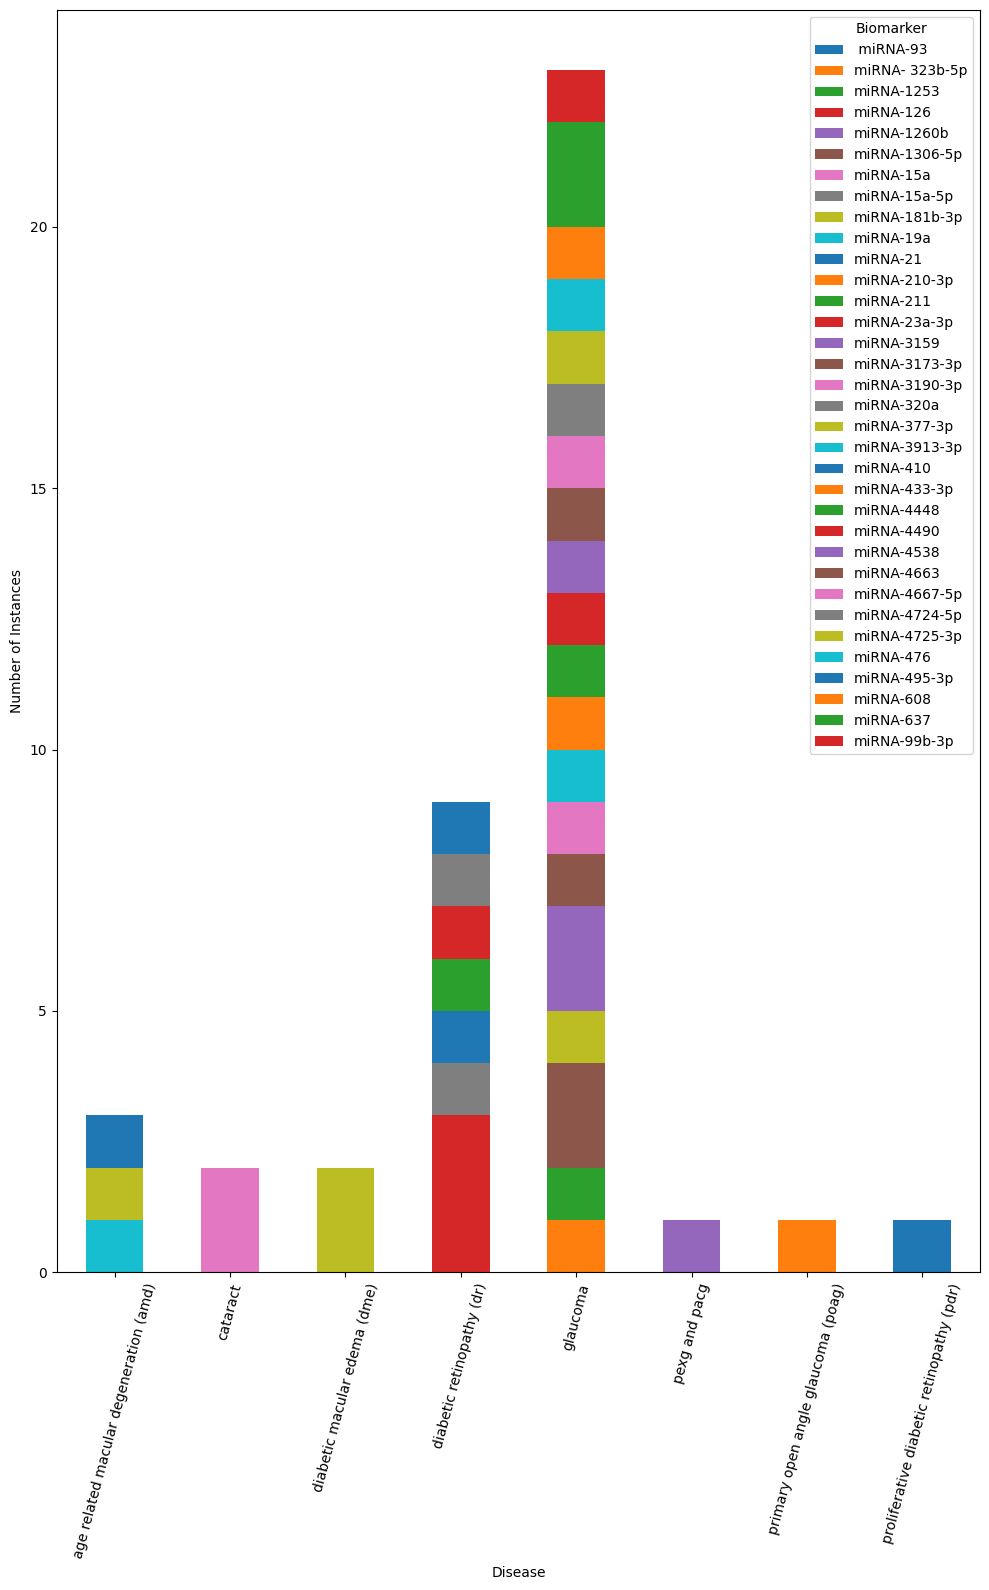

In [59]:
# Count occurrences of each biomarker for each disease
pivot_table = df2.pivot_table(index='disease', columns='Biomarker', aggfunc='size', fill_value=0)
# Plotting
pivot_table.plot(kind='bar', stacked=True, figsize=(10, 16), color=plt.cm.tab10.colors)
#plt.title('Biomarker Distribution by Disease')
plt.xlabel('Disease')
plt.ylabel('Number of Instances')
plt.xticks(rotation=75)
plt.legend(title='Biomarker')
plt.tight_layout()  # Adjust layout for better appearance
plt.savefig('Fig5.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_694/2139633320.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts, x='Count', y='Biomarker', palette='viridis')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


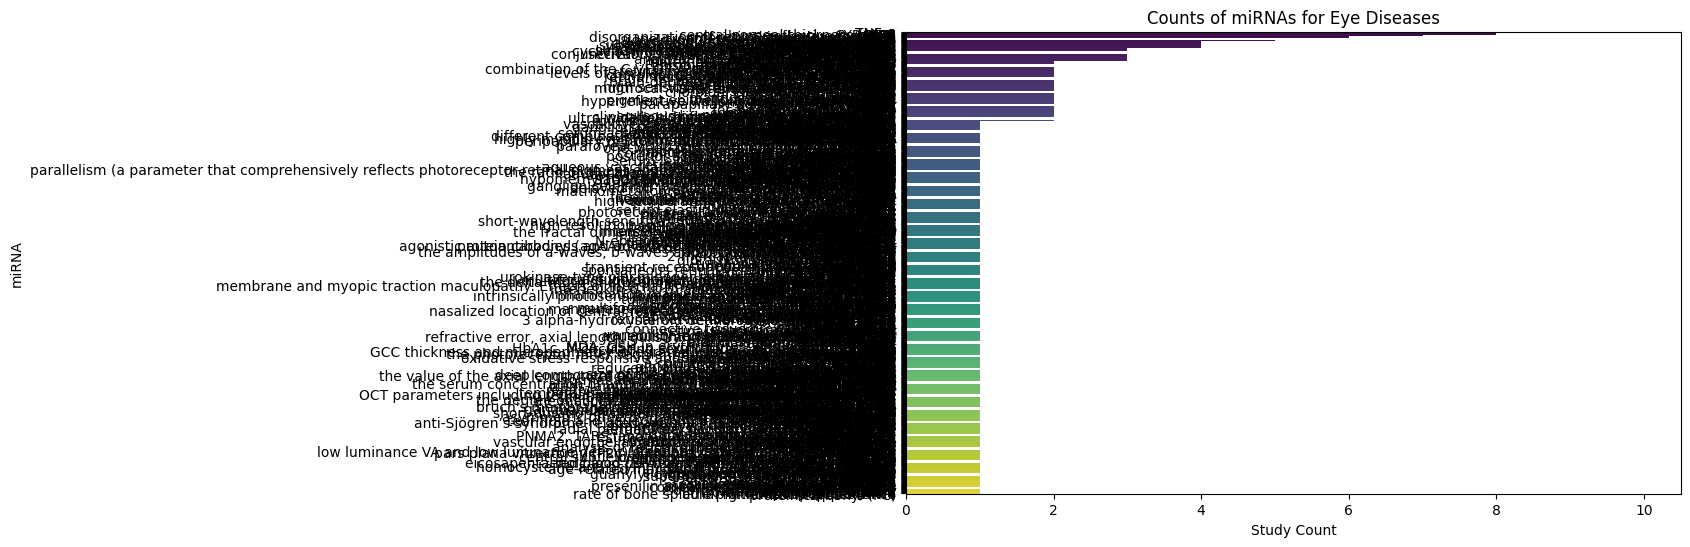

In [46]:
# 2. En çok tekrar eden miRNA’lar
counts = df['Biomarker'].value_counts().reset_index()
counts.columns = ['Biomarker','Count']
plt.figure(figsize=(10,6))
sns.barplot(data=counts, x='Count', y='Biomarker', palette='viridis')
plt.title('Counts of miRNAs for Eye Diseases')
plt.xlabel('Study Count')
plt.ylabel('miRNA')
plt.show();


In [ ]:
# MiRNA bazında sıralama
counts = df['Biomarker'].value_counts()
print(counts)
# En yüksek “Confidence” olanlar
# Önce “Confidence” sütunundaki “10/11” gibi değerleri sayısal olarak parse etmelisiniz
df['Confidence_num'] =df['Confidence'].str.split('/').str[0].astype(float)
top_conf = df.sort_values('Confidence_num', ascending=False).head(10)
print(top_conf[['Biomarker','Confidence','Region','Number']])

# Bölgelere göre dağılım
region_counts = df['Region'].value_counts()
print(region_counts)


Biomarker
TNF-α                                           10
IL-6                                             9
central corneal thickness (CCT)                  9
CYP46A1                                          8
CFH                                              8
                                                ..
APOH β-2-glycoprotein 1                          1
apolipoprotein A-IV                              1
atrial natriuretic peptide (ANP)                 1
rate of bone spicule pigmentation appearance     1
protein carbonyl (PC)                            1
Name: count, Length: 889, dtype: int64
                                             Biomarker Confidence  \
624                                             IGF-II      11/11   
625             tumour necrosis factor alpha -308 gene      11/11   
610                        skin autofluorescence (sAF)      11/11   
582                          hyperreflective foci (HF)      11/11   
583  the delta width of drusenoid pigment epi


En Yüksek Confidence Olanlar:
         Biomarker Confidence                  Region  Number
8   hsa-miR-210-3p      11/11  Guangdong, China, Asia      68
0          miR-126      10/11                  Europe    3250
9      miR-4667-5p      10/11                     NaN      64
2          miR-126      10/11                  Europe    3250
7          miR-211      10/11             China, Asia     120
5           miR-21      10/11             China, Asia     304
13        miR-1253      10/11                     NaN      64
12        miR-4490      10/11                     NaN      64

Bölgelere Göre Dağılım:
Region
Europe                    2
Egypt, Africa             2
Ireland                   2
China, Asia               2
Guangdong, China, Asia    1
Nanjing, China, Asia      1
Poland, Europe            1
Italy, Europe             1
Name: count, dtype: int64


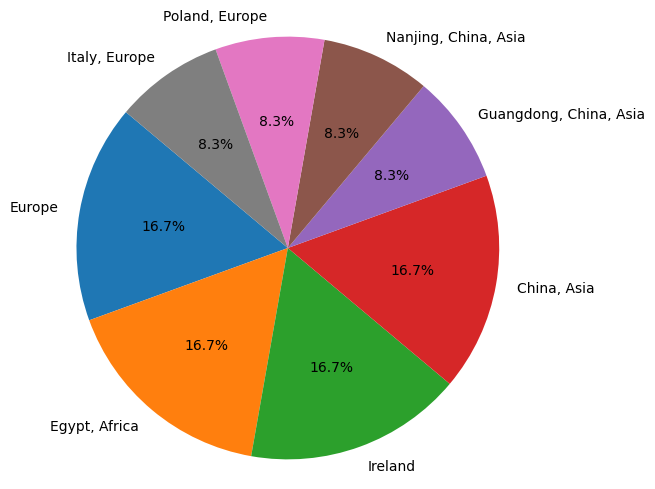

In [ ]:
counts.columns = ['Biomarker','Count']
# En yüksek “Confidence” olanlar
# Önce “Confidence” sütunundaki “10/11” gibi değerleri sayısal olarak parse etmelisiniz
df2['Confidence_num'] = df2['Confidence'].str.split('/').str[0].astype(float)
top_conf = df2.sort_values('Confidence_num', ascending=False).head(8)
print("\nEn Yüksek Confidence Olanlar:")
print(top_conf[['Biomarker', 'Confidence', 'Region', 'Number']])
# Bölgelere göre dağılım
region_counts = df2['Region'].value_counts()
print("\nBölgelere Göre Dağılım:")
print(region_counts)

# Pie chart visualization
plt.figure(figsize=(6, 6))
plt.pie(region_counts, labels=region_counts.index, autopct='%1.01f%%', startangle=140)
#plt.title('MiRNA Distribution by Region')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
#plt.savefig('Fig2.tiff', dpi=600, format='tiff', bbox_inches='tight')
plt.savefig('Fig2.png', dpi=300, format='png', bbox_inches='tight')
plt.show()

In [65]:
len(df2)

42

/tmp/ipykernel_694/1561023584.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_conf, x='Confidence_num', y='Biomarker', palette='magma')


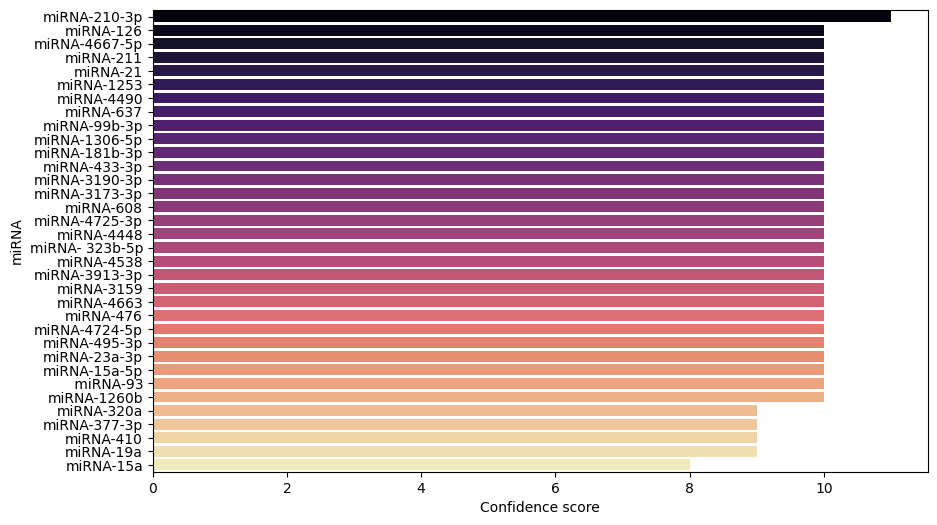

In [60]:
import seaborn as sns
# Önce “10/11” gibi stringleri sayıya çevirin:
df2['Confidence_num'] = df2['Confidence'].str.split('/').str[0].astype(float)
top_conf = df2.sort_values('Confidence_num', ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=top_conf, x='Confidence_num', y='Biomarker', palette='magma')
#plt.title('miRNAs with Confidence scores for Eye D')
plt.xlabel('Confidence score')
plt.ylabel('miRNA')
#plt.savefig('Fig3-n.tiff', dpi=600, format='tiff', bbox_inches='tight')
plt.savefig('Fig3.png', dpi=300, format='png', bbox_inches='tight')
plt.show()

              Value
count     42.000000
min        8.000000
max       11.000000
range      3.000000
mean       9.785714
median    10.000000
std        0.564637
variance   0.318815
skewness  -1.733305


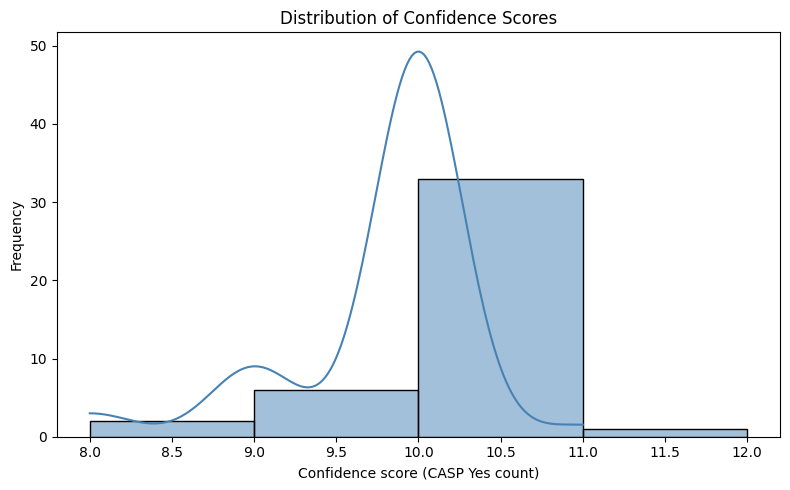

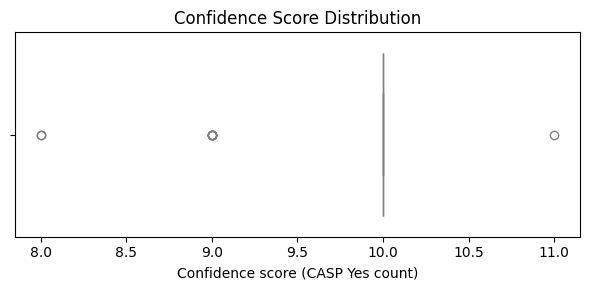

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Confidence string -> numeric (numerator only, e.g. "10/11" -> 10)
df2['Confidence_num'] = df2['Confidence'].str.split('/').str[0].astype(float)

# -----------------------------
# Summary statistics
# -----------------------------
summary_stats = {
    "count": df2['Confidence_num'].count(),
    "min": df2['Confidence_num'].min(),
    "max": df2['Confidence_num'].max(),
    "range": df2['Confidence_num'].max() - df2['Confidence_num'].min(),
    "mean": df2['Confidence_num'].mean(),
    "median": df2['Confidence_num'].median(),
    "std": df2['Confidence_num'].std(),
    "variance": df2['Confidence_num'].var(),
    "skewness": df2['Confidence_num'].skew()
}

summary_df = pd.DataFrame.from_dict(summary_stats, orient='index', columns=['Value'])
print(summary_df)

# -----------------------------
# Distribution plot
# -----------------------------
plt.figure(figsize=(8,5))
sns.histplot(
    df2['Confidence_num'],
    bins=range(int(df2['Confidence_num'].min()), int(df2['Confidence_num'].max()) + 2),
    kde=True,
    color='steelblue'
)
plt.xlabel('Confidence score (CASP Yes count)')
plt.ylabel('Frequency')
plt.title('Distribution of Confidence Scores')
plt.tight_layout()
plt.show()

# -----------------------------
# Boxplot for spread and median
# -----------------------------
plt.figure(figsize=(6,3))
sns.boxplot(
    x=df2['Confidence_num'],
    color='lightgray'
)
plt.xlabel('Confidence score (CASP Yes count)')
plt.title('Confidence Score Distribution')
plt.tight_layout()
plt.show()


In [61]:
# 6) Klinik uygulama kategorisi FOR DR(prediction / prognosis / etc.)
application_counts = df2['Application'].value_counts()
print("\n🔹 Clinical Application types:\n", application_counts)


🔹 Clinical Application types:
 Application
diagnosis     36
treatment      2
prediction     2
prognosis      1
Name: count, dtype: int64


In [62]:
# 6) Klinik uygulama kategorisi (prediction / prognosis / etc.)
application_counts = df['Application'].value_counts()
print("\n🔹 Clinical Application types:\n", application_counts)


🔹 Clinical Application types:
 Application
prediction               528
diagnosis                319
prognosis                226
treatment                 39
progression               37
diagnosis/prediction       5
diagnosis/prognosis        2
prognosis/treatment        2
prognosis/risk factor      1
diagnosis/treatment        1
treatment/prognosis        1
prediction/diagnosis       1
Name: count, dtype: int64


In [63]:
# 5) Pathway/Fonksiyonel bilgi
# KEGG, Reactome, GO kolonları dolu mu, hangi genlerde var?
pathway_info = df[['Officialsymbol','KEGG','Reactome','Gene_ontology']].dropna(how='all')

pathway_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 519 entries, 0 to 1196
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Officialsymbol  497 non-null    object
 1   KEGG            270 non-null    object
 2   Reactome        240 non-null    object
 3   Gene_ontology   272 non-null    object
dtypes: object(4)
memory usage: 20.3+ KB


In [64]:
# 6) Klinik uygulama kategorisi (prediction / prognosis / etc.)
application_counts = df['Application'].value_counts()
print("\n🔹 Clinical Application types:\n", application_counts)


🔹 Clinical Application types:
 Application
prediction               528
diagnosis                319
prognosis                226
treatment                 39
progression               37
diagnosis/prediction       5
diagnosis/prognosis        2
prognosis/treatment        2
prognosis/risk factor      1
diagnosis/treatment        1
treatment/prognosis        1
prediction/diagnosis       1
Name: count, dtype: int64


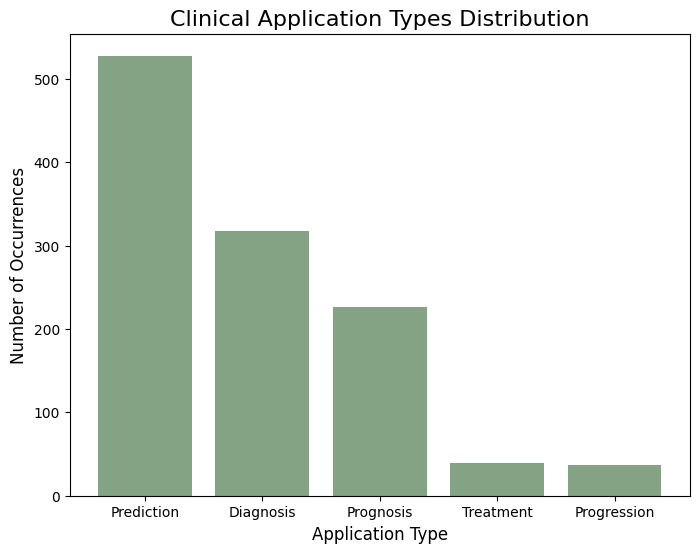

In [ ]:
import matplotlib.pyplot as plt
categories = ['Prediction', 'Diagnosis', 'Prognosis', 'Treatment', 'Progression']
values = [528, 318, 226, 39, 37]

# Create a bar chart
plt.figure(figsize=(8, 6))
color = (0.2, # redness
         0.4, # greenness
         0.2, # blueness
         0.6 # transparency
         )
plt.bar(categories, values, color=color)

# Add titles and labels
plt.title('Clinical Application Types Distribution', fontsize=16)
plt.xlabel('Application Type', fontsize=12)
plt.ylabel('Number of Occurrences', fontsize=12)
plt.savefig('Fig_app.png', dpi=300, bbox_inches='tight')
# Show the chart
plt.show()


In [ ]:
pip install bio2bel_mirtarbase

INFO: pip is looking at multiple versions of bio2bel-hgnc to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 104.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.7/284.7 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.8/80.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 525.6/525.6 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.5/152.5 kB 15.7 MB/s eta 0:00:00
  Created wheel for flasgger: filename=flasgger-0.9.7.1-py2.py3-none-any.whl size=3865185 sha256=9843dfb7d8e9e08788534104e3cfc5adbafe508b5aaf53711e56111e40b70ab6
  Stored in directory: /root/.cache/pip/wheels/60/a4/b2/76a769725ac2f2c543a6286cddf2bd55b425a9ada6a8f86253
Successfully built flasgger


In [ ]:
pip install --upgrade sqlalchemy

In [ ]:
pip install sqlalchemy_utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 5.1 MB/s eta 0:00:00


In [ ]:
pip install Flask-SQLAlchemy

In [ ]:
pip install bio2bel-mirtarbase


In [ ]:
pip install flask-sqlalchemy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 66.9 MB/s eta 0:00:00
  Attempting uninstall: sqlalchemy
    Found existing installation: SQLAlchemy 1.4.0
    Uninstalling SQLAlchemy-1.4.0:
      Successfully uninstalled SQLAlchemy-1.4.0


In [ ]:
from sqlalchemy_utils import create_database, database_exists # Correct

AttributeError: module 'sqlalchemy.dialects.postgresql.json' has no attribute 'JSONPATH'

In [ ]:
pip install sqlalchemy_utils

In [ ]:
import bio2bel_mirtarbase
mirtarbase_manager = bio2bel_mirtarbase.Manager()
mirtarbase_manager.populate()

ModuleNotFoundError: No module named 'sqlalchemy.ext.declarative.api'

In [ ]:
pip install gseapy pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 605.3/605.3 kB 35.5 MB/s eta 0:00:00


In [ ]:
# ------------------------------
# 1) Diabetic Retinopathy satırlarını filtrele
# ------------------------------
df_dr = df[df['disease'] == 'diabetic retinopathy (dr)'].copy()

# ------------------------------
# 2) Sonuçları kontrol et
# ------------------------------
print(df_dr.shape)       # kaç satır ve sütun geldiğini gösterir
print(df_dr.head())      # ilk 5 satırı gösterir


(224, 42)
              Biomarker                    disease  \
23   pentraxin-3 (PTX3)  diabetic retinopathy (dr)   
105                RAGE  diabetic retinopathy (dr)   
106             AVR-BVC  diabetic retinopathy (dr)   
111                CTGF  diabetic retinopathy (dr)   
112             miR-126  diabetic retinopathy (dr)   

                                           url                      Category4  \
23   https://pubmed.ncbi.nlm.nih.gov/28574494/                        Protein   
105  https://pubmed.ncbi.nlm.nih.gov/19542745/  Nucleic Acids-Based Biomarker   
106  https://pubmed.ncbi.nlm.nih.gov/30326063/                    Bio-imaging   
111  https://pubmed.ncbi.nlm.nih.gov/15258030/  Nucleic Acids-Based Biomarker   
112  https://pubmed.ncbi.nlm.nih.gov/27696070/  Nucleic Acids-Based Biomarker   

                                           Discription                 Region  \
23   Pentraxin protein superfamily is composed of\n...  Ataturk, Turkey, Asia   
105  In 2001, 17

In [ ]:
# ------------------------------
# 1) Paketler
# ------------------------------
import pandas as pd
import gseapy as gp

# ------------------------------
# 2) Biomarker listesini al
# ------------------------------
genes = df_dr['Biomarker'].dropna().unique().tolist()
print(f"Toplam gen sayısı: {len(genes)}")

# ------------------------------
# 3) KEGG Pathway Enrichment
# ------------------------------
kegg = gp.enrichr(
    gene_list=genes,
    gene_sets='KEGG_2021_Human',   # KEGG pathway
    organism='Human',
    outdir='KEGG_DR',              # Çıktı klasörü
    cutoff=1.05                     # p-value cutoff
)

# ------------------------------
# 4) Sadece metabolic pathways (opsiyonel)
# ------------------------------
metabolic = kegg.results[kegg.results['Term'].str.contains("metabolism|Metabolic", case=False)]
metabolic.to_csv("KEGG_DR_metabolic_pathways.csv", index=False)

# ------------------------------
# 5) İlk 5 sonucu göster
# ------------------------------
print(metabolic.head())


Toplam gen sayısı: 196
Empty DataFrame
Columns: [Gene_set, Term, Overlap, P-value, Adjusted P-value, Old P-value, Old Adjusted P-value, Odds Ratio, Combined Score, Genes]
Index: []


In [ ]:
pip install  pubchempy

In [ ]:
pip install rdkit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 55.6 MB/s eta 0:00:00


In [ ]:
pip install py3Dmol

In [ ]:
pip install bioservices

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.0/258.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.3/145.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 720.1/720.1 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 17.4 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing insta

In [ ]:
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
import pubchempy as pcp
import pandas as pd
import sys
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.ipython_3d = True
import py3Dmol
from rdkit.Chem import rdDepictor
from rdkit.Chem import rdDistGeom
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit import DataStructs
import numpy as np
import pubchempy as pcp
import bioservices
from bioservices import KEGG

ModuleNotFoundError: No module named 'py3Dmol'

In [ ]:
file = "metabolite_.xlsx"
df = pd.read_excel('metabolite_.xlsx')

In [ ]:
len(df)

44

In [ ]:
df= df.rename(columns={"kegg_id": "Compound_ID"})
df2.head()


,Biomarker,disease,url,Category4,Discription,Region,Race,Number,Gender,Age,...,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Confidence,Confidence_num
0,miR-126,diabetic retinopathy (dr),https://pubmed.ncbi.nlm.nih.gov/27696070/,Nucleic Acids-Based Biomarker,"MicroRNAs (miRNAs) are small, nonprotein-encod...",Europe,European,3250,NaN,NaN,...,Yes,Yes,Yes,Can't tell,Yes,Yes,Yes,Yes,10/11,10.0
1,hsa-miR-15a,cataract,https://pubmed.ncbi.nlm.nih.gov/31264507/,Nucleic Acids-Based Biomarker,this miRNA with the expression of its target a...,"Egypt, Africa",African,160,84/66,58.8±2.9; 57.9±1.2,...,Yes,Can't tell,Yes,Can't tell,Yes,Yes,Can't tell,Yes,8/11,8.0
2,miR-126,diabetic retinopathy (dr),https://pubmed.ncbi.nlm.nih.gov/27696070/,Nucleic Acids-Based Biomarker,"MicroRNAs (miRNAs) are small, nonprotein-encod...",Europe,European,3250,NaN,NaN,...,Yes,Yes,Yes,Can't tell,Yes,Yes,Yes,Yes,10/11,10.0
3,miR-377-3p,age related macular degeneration (amd),https://pubmed.ncbi.nlm.nih.gov/33906524/,Nucleic Acids-Based Biomarker,"hus far, the role of serum exosomal microRNAs ...",NaN,NaN,44,NaN,NaN,...,Yes,No,Yes,Yes,Yes,Yes,Can't tell,Yes,9/11,9.0
4,miR-410,age related macular degeneration (amd),https://pubmed.ncbi.nlm.nih.gov/32818115/,Nucleic Acids-Based Biomarker,MicroRNAs (miRNAs) are small noncoding RNAs th...,Ireland,NaN,377,NaN,NaN,...,Yes,Yes,Yes,Yes,Can't tell,Can't tell,Yes,Yes,9/11,9.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 42 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Biomarker       1197 non-null   object 
 1   disease         1168 non-null   object 
 2   url             1197 non-null   object 
 3   Category4       1197 non-null   object 
 4   Discription     517 non-null    object 
 5   Region          678 non-null    object 
 6   Race            552 non-null    object 
 7   Number          1197 non-null   int64  
 8   Gender          435 non-null    object 
 9   Age             540 non-null    object 
 10  odos            350 non-null    object 
 11  Source          1149 non-null   object 
 12  Experiment      1139 non-null   object 
 13  Statictics      1130 non-null   object 
 14  Application     1162 non-null   object 
 15  Conclusion      1194 non-null   object 
 16  Reference       1197 non-null   object 
 17  PMID            1197 non-null   i

In [ ]:
compound_ids= df["Compound_ID"].tolist()
compound_ids = [str(cid).strip() for cid in compound_ids if pd.notna(cid)]

In [ ]:
import pandas as pd
from bioservices import KEGG
kegg = KEGG()
results = []
# ID'leri string'e çevir ve boş olanları atla
compound_ids = [str(cid).strip() for cid in compound_ids if pd.notna(cid)]
#compound_ids = ['C00092']  # Pyruvate — çok sayıda pathway'de yer alır
for compound_id in compound_ids:
    try:
        entry = kegg.get(compound_id)
        # Eğer entry metin değilse (None, int vs) atla
        if not isinstance(entry, str):
            print(f"⚠️ Uyarı: {compound_id} için veri alınamadı.")
            continue
        lines = entry.split('\n')
        for line in lines:
            if line.startswith('PATHWAY'):
                pathway_id = str(line[12:20].strip())
                pathway_name = str(line[20:].strip())
                results.append({
                    "Compound_ID": compound_id,
                    "Pathway_ID": pathway_id,
                    "Pathway_Name": pathway_name
                })

    except Exception as e:
        print(f"❌ Hata: {compound_id} için işlem başarısız -> {e}")
# DataFrame'e aktar
df2 = pd.DataFrame(results)
print(df2)

# Yolak ID ve isimlerini birleştiren sütunlar oluştur
pathway_combined = df2.groupby("Compound_ID").agg({
    "Pathway_ID": lambda x: ', '.join(sorted(set(x))),
    "Pathway_Name": lambda x: '; '.join(sorted(set(x)))
}).rename(columns={
    "Pathway_ID": "All_Pathway_IDs",
    "Pathway_Name": "All_Pathway_Names"
})

# Bu birleştirilmiş sütunları mevcut df'ye birleştir
df2 = df2.merge(pathway_combined, on="Compound_ID", how="left")

Creating directory /root/.config/bioservices 
Creating directory /root/.cache/bioservices 
Welcome to Bioservices
It looks like you do not have a configuration file.
We are creating one with default values in /root/.config/bioservices/bioservices.cfg .
Done
   Compound_ID Pathway_ID                                       Pathway_Name
0       C00007   map00190                          Oxidative phosphorylation
1       C00750   map00330                    Arginine and proline metabolism
2       C00134   map00330                    Arginine and proline metabolism
3       C00315   map00330                    Arginine and proline metabolism
4       C00037   map00120                     Primary bile acid biosynthesis
5       C00745   map00760             Nicotinate and nicotinamide metabolism
6       C01673   map00100                               Steroid biosynthesis
7       C00422   map00561                            Glycerolipid metabolism
8       C00805   map00621                        

In [ ]:
df.head()

,Compound_ID,Pathway_ID,Pathway_Name,All_Pathway_IDs,All_Pathway_Names
0,C00007,map00190,Oxidative phosphorylation,map00190,Oxidative phosphorylation
1,C00750,map00330,Arginine and proline metabolism,map00330,Arginine and proline metabolism
2,C00134,map00330,Arginine and proline metabolism,map00330,Arginine and proline metabolism
3,C00315,map00330,Arginine and proline metabolism,map00330,Arginine and proline metabolism
4,C00037,map00120,Primary bile acid biosynthesis,map00120,Primary bile acid biosynthesis


In [ ]:
len(df2)

33

In [ ]:
# Sonuçları tutmak için yapı
data = {
    "Compound_ID": [],
    "Pathway_ID": [],
    "Pathway_Name": [],
    "All_Pathway_IDs": [],
    "All_Pathway_Names": []
}
for compound_id in compound_ids:
    try:
        entry = kegg.get(compound_id)

        if not isinstance(entry, str):
            data["Compound_ID"].append(compound_id)
            data["Pathway_ID"].append("")
            data["Pathway_Name"].append("")
            data["All_Pathway_IDs"].append("Entry not found")
            data["All_Pathway_Names"].append("Entry not found")
            continue

        lines = entry.split('\n')
        pathways = []

        for line in lines:
            if line.startswith("PATHWAY"):
                parts = line.strip().split("PATHWAY")[1].strip().split("  ", 1)
            elif line.startswith(" "):  # PATHWAY satırının devamı olabilir
                parts = line.strip().split("  ", 1)
            else:
                continue

            if len(parts) == 2:
                pid, pname = parts
                pathways.append((pid.strip(), pname.strip()))

        if pathways:
            all_ids = "; ".join([pid for pid, _ in pathways])
            all_names = "; ".join([pname for _, pname in pathways])

            first_pid, first_pname = pathways[0]

            data["Compound_ID"].append(compound_id)
            data["Pathway_ID"].append(first_pid)
            data["Pathway_Name"].append(first_pname)
            data["All_Pathway_IDs"].append(all_ids)
            data["All_Pathway_Names"].append(all_names)
        else:
            data["Compound_ID"].append(compound_id)
            data["Pathway_ID"].append("")
            data["Pathway_Name"].append("")
            data["All_Pathway_IDs"].append("No pathways found")
            data["All_Pathway_Names"].append("No pathways found")

    except Exception as e:
        data["Compound_ID"].append(compound_id)
        data["Pathway_ID"].append("")
        data["Pathway_Name"].append("")
        data["All_Pathway_IDs"].append(f"Error: {str(e)}")
        data["All_Pathway_Names"].append(f"Error: {str(e)}")

# Sonuçları DataFrame olarak göster
df_pathways = pd.DataFrame(data)
df_pathways.head()

,Compound_ID,Pathway_ID,Pathway_Name,All_Pathway_IDs,All_Pathway_Names
0,C19440,1,C4a C 26.8330 -19.1806,1; 2; 3; 4; 5; 1; 2; 3; 4,C4a C 26.8330 -19.1806; C1b C 28.0455 ...
1,C00007,map00190,Oxidative phosphorylation,map00190; map00195; map00630; map00910; map011...,Oxidative phosphorylation; Photosynthesis; Gly...
2,C00750,map00330,Arginine and proline metabolism,map00330; map00410; map00480; map00770; map011...,Arginine and proline metabolism; beta-Alanine ...
3,C00134,map00330,Arginine and proline metabolism,map00330; map00470; map00480; map00960; map009...,Arginine and proline metabolism; D-Amino acid ...
4,C00315,map00330,Arginine and proline metabolism,map00330; map00410; map00480; map00940; map009...,Arginine and proline metabolism; beta-Alanine ...


In [ ]:
df_pathways.head()

,Compound_ID,Pathway_ID,Pathway_Name,All_Pathway_IDs,All_Pathway_Names
0,C19440,1,C4a C 26.8330 -19.1806,1; 2; 3; 4; 5; 1; 2; 3; 4,C4a C 26.8330 -19.1806; C1b C 28.0455 ...
1,C00007,map00190,Oxidative phosphorylation,map00190; map00195; map00630; map00910; map011...,Oxidative phosphorylation; Photosynthesis; Gly...
2,C00750,map00330,Arginine and proline metabolism,map00330; map00410; map00480; map00770; map011...,Arginine and proline metabolism; beta-Alanine ...
3,C00134,map00330,Arginine and proline metabolism,map00330; map00470; map00480; map00960; map010...,Arginine and proline metabolism; D-Amino acid ...
4,C00315,map00330,Arginine and proline metabolism,map00330; map00410; map00480; map00940; map010...,Arginine and proline metabolism; beta-Alanine ...


In [ ]:
df_pathways1 = df_pathways[df_pathways["Pathway_ID"].str.startswith("map", na=True)]
df_pathways1.head()

,Compound_ID,Pathway_ID,Pathway_Name,All_Pathway_IDs,All_Pathway_Names
1,C00007,map00190,Oxidative phosphorylation,map00190; map00195; map00630; map00910; map011...,Oxidative phosphorylation; Photosynthesis; Gly...
2,C00750,map00330,Arginine and proline metabolism,map00330; map00410; map00480; map00770; map011...,Arginine and proline metabolism; beta-Alanine ...
3,C00134,map00330,Arginine and proline metabolism,map00330; map00470; map00480; map00960; map009...,Arginine and proline metabolism; D-Amino acid ...
4,C00315,map00330,Arginine and proline metabolism,map00330; map00410; map00480; map00940; map009...,Arginine and proline metabolism; beta-Alanine ...
5,C00037,map00120,Primary bile acid biosynthesis,map00120; map00230; map00260; map00310; map004...,Primary bile acid biosynthesis; Purine metabol...


In [ ]:
len(df_pathways1)

33

In [ ]:
# Küçük harfe çevir + boşlukları temizle
df['Compound_ID'] = df['Compound_ID'].astype(str).str.strip().str.lower()
df_pathways1['Compound_ID'] = df_pathways1['Compound_ID'].astype(str).str.strip().str.lower()

/tmp/ipython-input-3591768328.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pathways1['Compound_ID'] = df_pathways1['Compound_ID'].astype(str).str.strip().str.lower()


In [ ]:
df_merged = pd.merge(df_pathways1, df, how='left', on='Compound_ID')

In [ ]:
df_merged = df_merged.dropna(subset=['Pathway_ID'])
df_merged.head()

,Compound_ID,Pathway_ID,Pathway_Name,All_Pathway_IDs,All_Pathway_Names,BID,Biomarker,Smiles,disease,url,...,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Confidence
0,c00007,map00190,Oxidative phosphorylation,map00190; map00195; map00630; map00910; map011...,Oxidative phosphorylation; Photosynthesis; Gly...,56,superoxide,[O-][O],age-related cataracts,https://pubmed.ncbi.nlm.nih.gov/26125826/,...,Yes,Yes,Yes,Yes,Can't tell,Yes,Yes,Yes,Yes,10/11
1,c00750,map00330,Arginine and proline metabolism,map00330; map00410; map00480; map00770; map011...,Arginine and proline metabolism; beta-Alanine ...,162,spermine,C(CCNCCCN)CNCCCN,proliferative diabetic retinopathy (PDR),https://pubmed.ncbi.nlm.nih.gov/12881351/,...,Yes,Yes,Yes,Yes,Can't tell,Yes,Yes,Yes,Yes,10/11
2,c00134,map00330,Arginine and proline metabolism,map00330; map00470; map00480; map00960; map009...,Arginine and proline metabolism; D-Amino acid ...,163,putrescine,C(CCN)CN,proliferative diabetic retinopathy and prolife...,https://pubmed.ncbi.nlm.nih.gov/12881351/,...,Yes,Yes,Yes,Yes,Can't tell,Yes,Yes,Yes,Yes,10/11
3,c00315,map00330,Arginine and proline metabolism,map00330; map00410; map00480; map00940; map009...,Arginine and proline metabolism; beta-Alanine ...,164,spermidine,C(CCNCCCN)CN,proliferative diabetic retinopathy and prolife...,https://pubmed.ncbi.nlm.nih.gov/12881351/,...,Yes,Yes,Yes,Yes,Can't tell,Yes,Yes,Yes,Yes,10/11
4,c00037,map00120,Primary bile acid biosynthesis,map00120; map00230; map00260; map00310; map004...,Primary bile acid biosynthesis; Purine metabol...,284,glycine,NCC(=O)O,primary congenital glaucoma (PCG),https://pubmed.ncbi.nlm.nih.gov/31588173/,...,Yes,Yes,Can't tell,Yes,Can't tell,Yes,Yes,Can't tell,Yes,8/11


In [ ]:
len(df_merged)

33

In [ ]:
pip install pandas networkx matplotlib


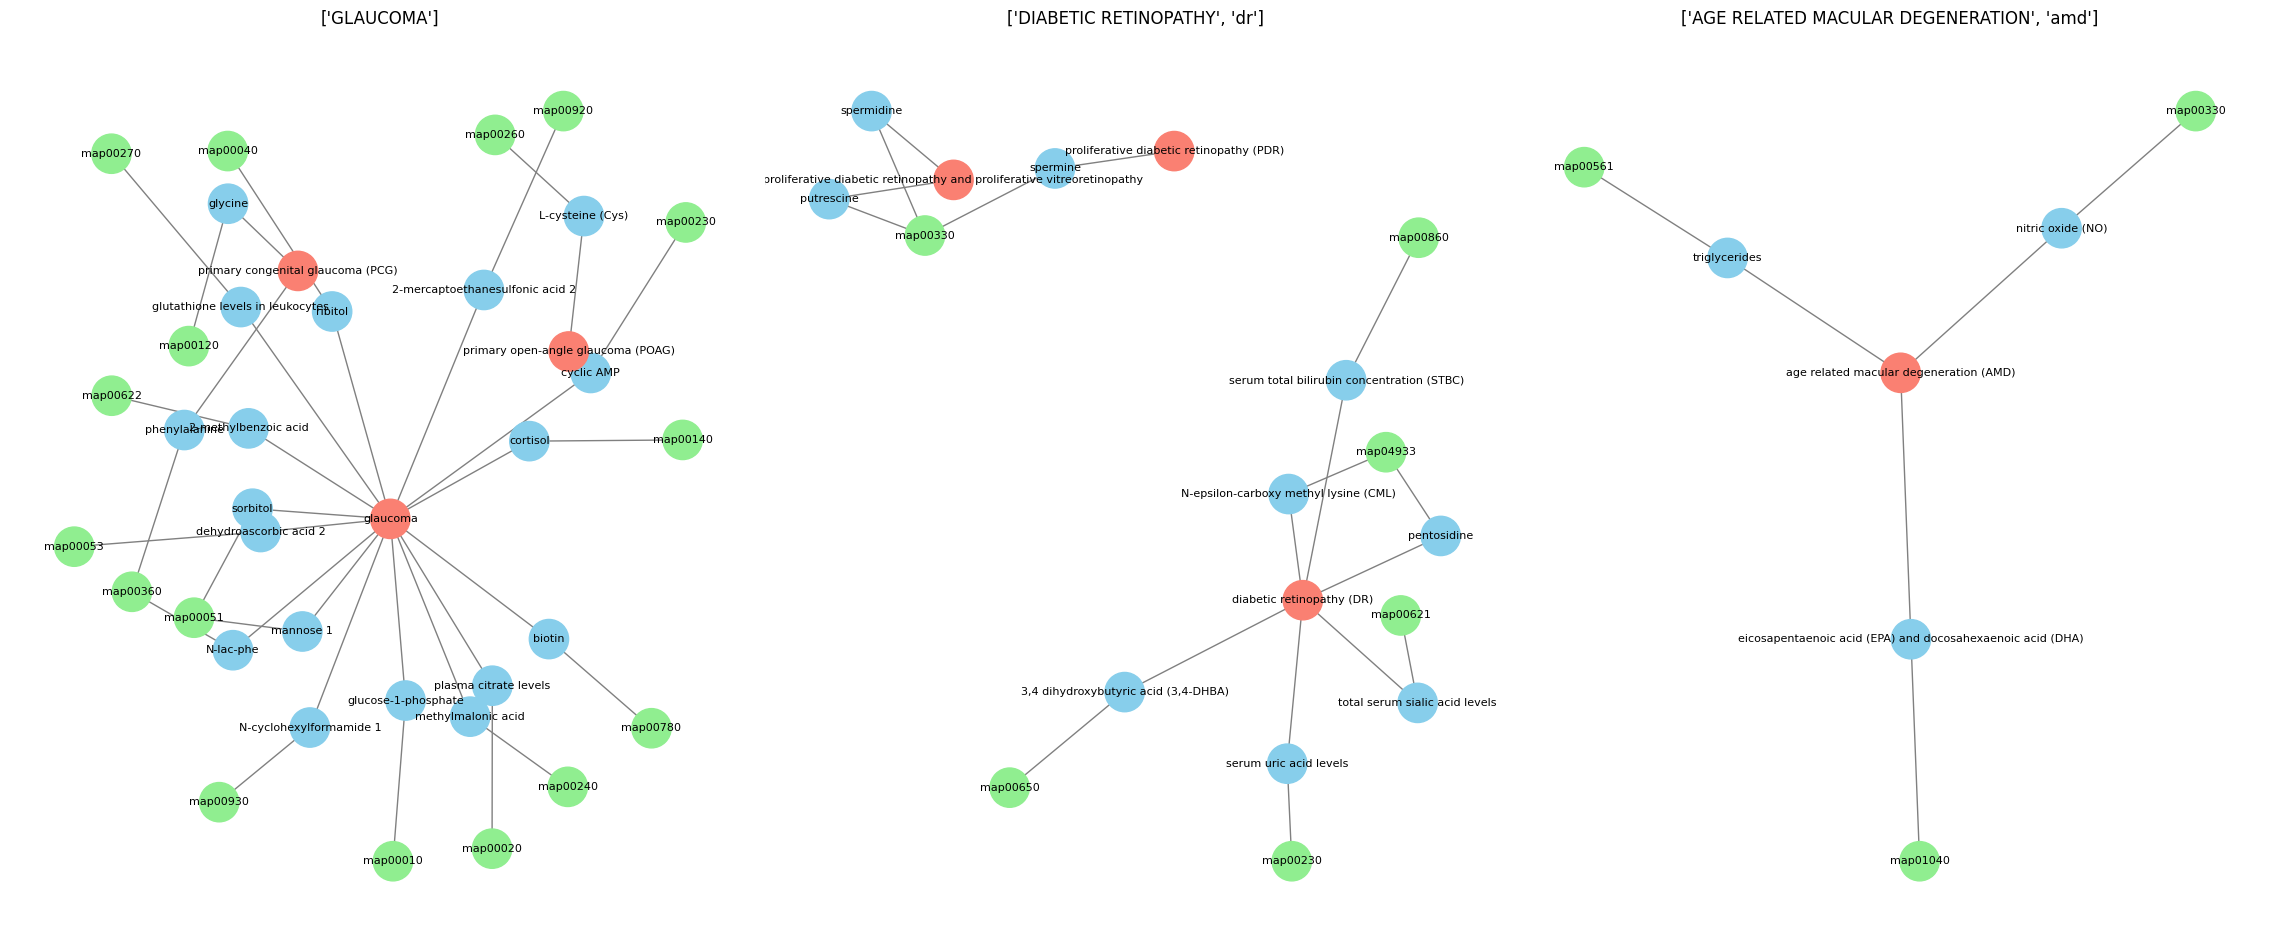

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
diseases = {
    "glaucoma": ["GLAUCOMA"],
    "diabetic retinopathy": ["DIABETIC RETINOPATHY", "dr"],
    "age related macular degeneration": ["AGE RELATED MACULAR DEGENERATION", "amd"]
}

# Tek figür, 1 satır 3 sütun
fig, axs = plt.subplots(1, 3, figsize=(38, 12))
#fig.suptitle("Metabolik Network Grafikleri", fontsize=20)

for i, (keyword, title) in enumerate(diseases.items()):
    ax = axs[i]

    # Hastalığa ait satırları filtrele (küçük harfe çevir, varsa substring)
    df_disease = df_merged[df_merged['disease'].str.contains(keyword, case=False, na=False)]
    if df_disease.empty:
        ax.set_title(f"{title}\nVeri yok")
        ax.axis('off')
        continue

    # Network graph oluştur
    G = nx.Graph()

    for _, row in df_disease.iterrows():
        biomarker = row['Biomarker']
        disease = row['disease']
        pathway_id = row['Pathway_ID']
        pathway_name = row['Pathway_Name']

        # Düğümler
        G.add_node(biomarker, type='biomarker')
        G.add_node(disease, type='disease')
        G.add_node(pathway_id, type='pathway', label=pathway_name)

        # Kenarlar
        G.add_edge(biomarker, disease)
        G.add_edge(biomarker, pathway_id)

    # Node renklerini belirle
    color_map = []
    for node in G.nodes(data=True):
        ntype = node[1].get('type', '')
        if ntype == 'biomarker':
            color_map.append('skyblue')
        elif ntype == 'disease':
            color_map.append('salmon')
        elif ntype == 'pathway':
            color_map.append('lightgreen')
        else:
            color_map.append('grey')

    # Layout
    pos = nx.spring_layout(G, seed=42, k=0.58)

    # Grafik çizimi
    nx.draw(G, pos, ax=ax, node_color=color_map, with_labels=True, font_size=8,
            node_size=800, edge_color='gray')

    # Başlık
    ax.set_title(title)

    # Eksenleri kapat
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 0.6, 0.8])
plt.savefig('Fignetwork.png', dpi=300, format='png', bbox_inches='tight')
plt.show()


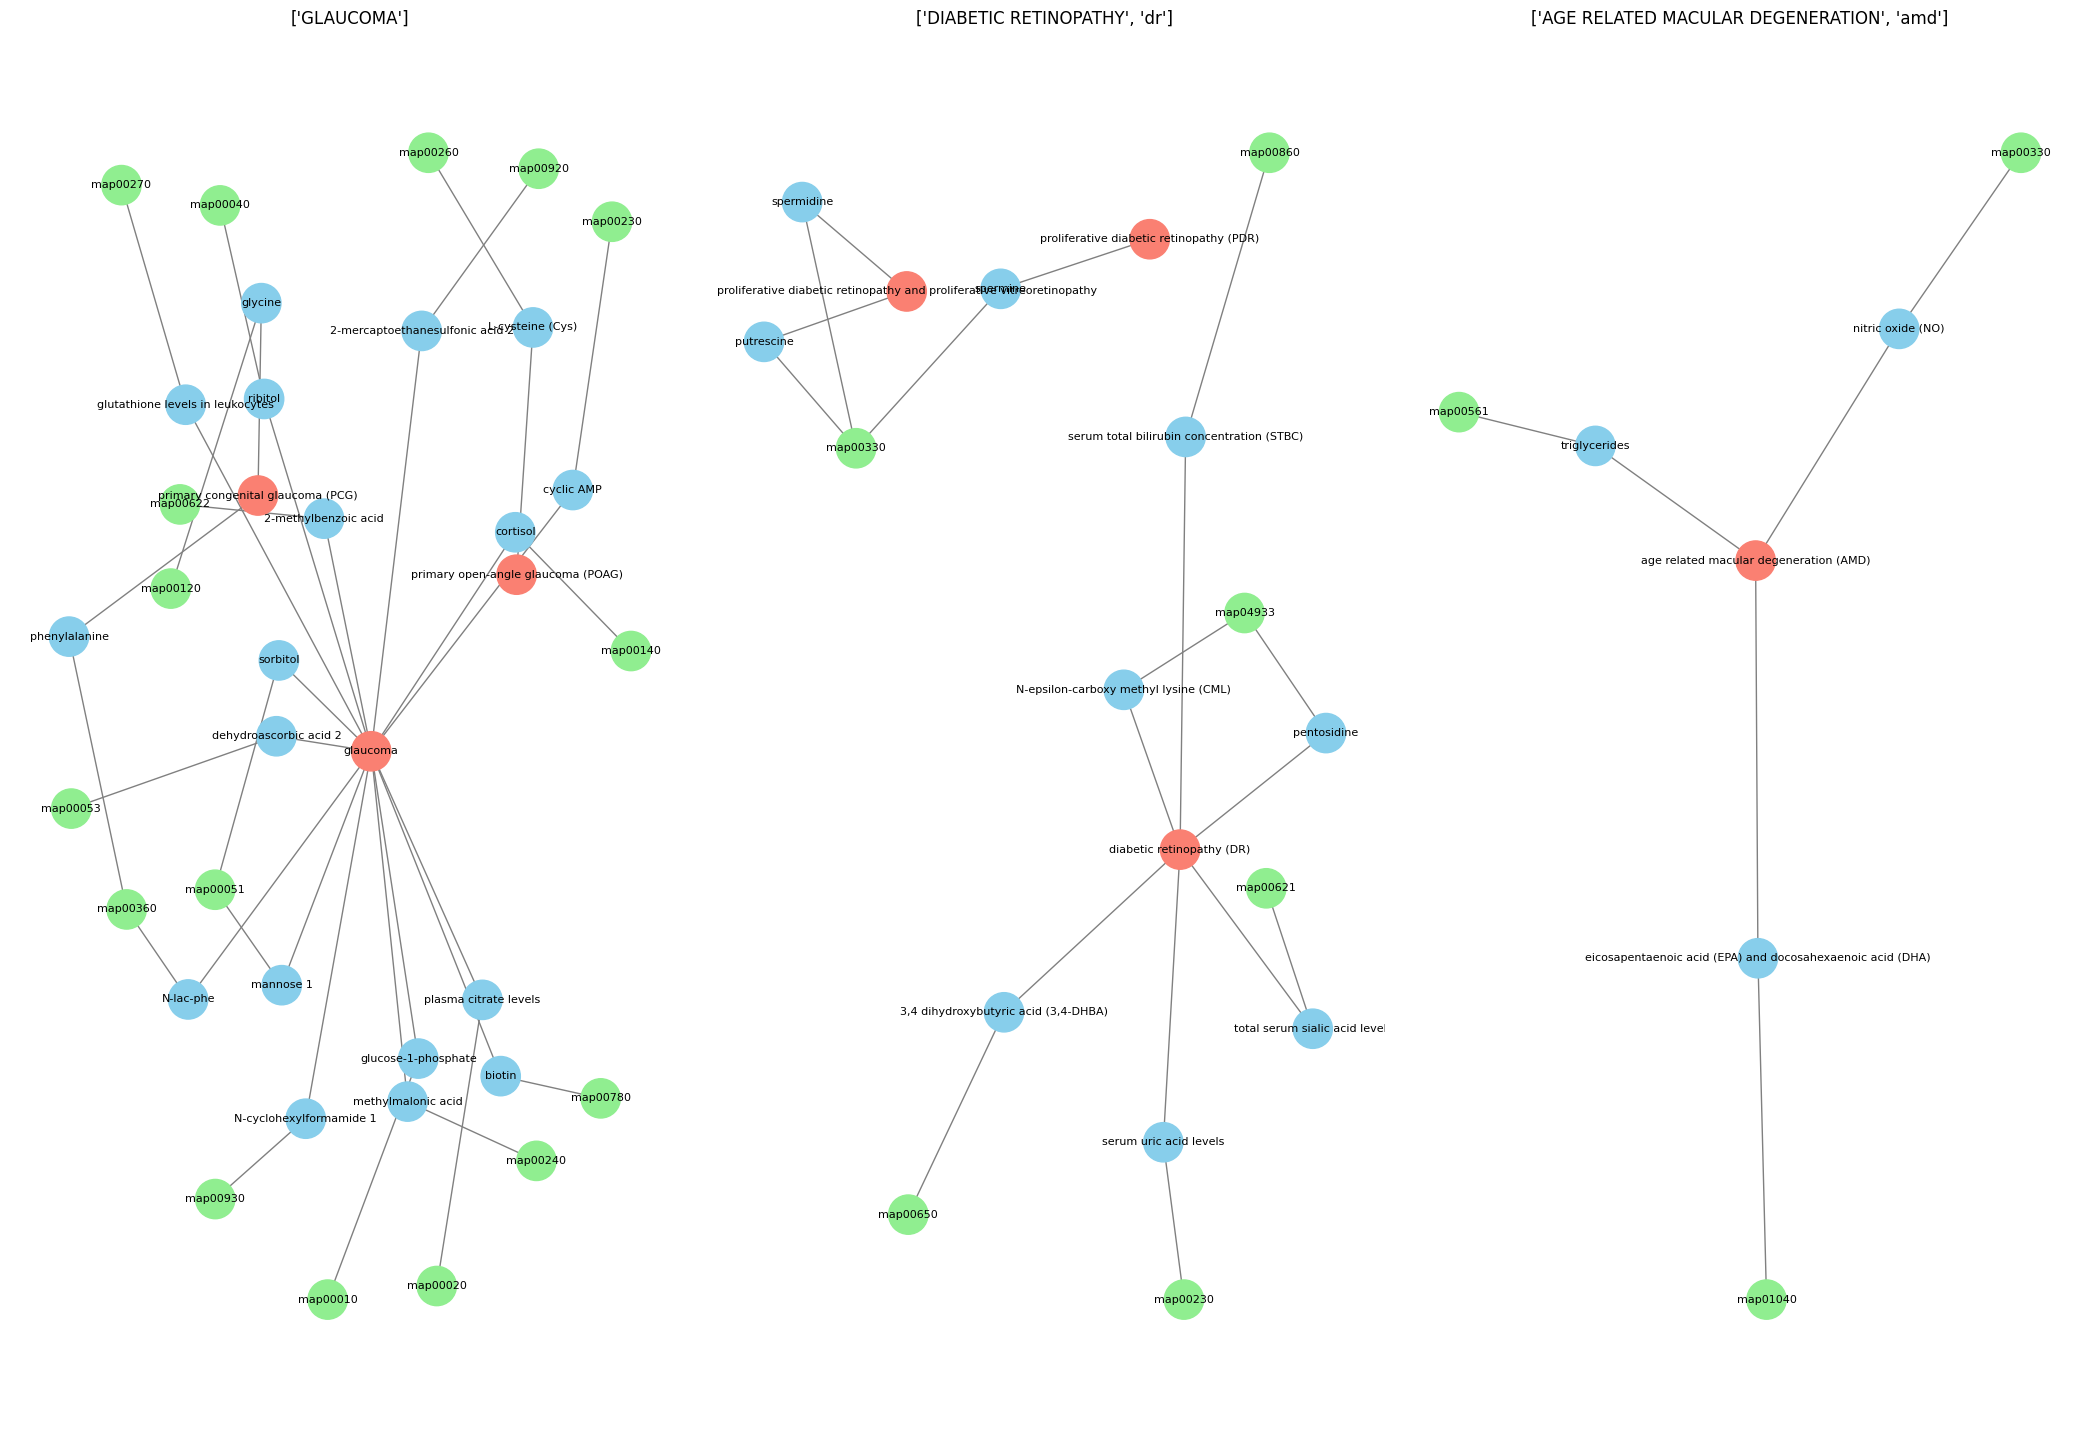

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Example data structure, replace with your actual data
diseases = {
    "glaucoma": ["GLAUCOMA"],
    "diabetic retinopathy": ["DIABETIC RETINOPATHY", "dr"],
    "age related macular degeneration": ["AGE RELATED MACULAR DEGENERATION", "amd"]
}

# Tek figür, 1 satır 3 sütun
fig, axs = plt.subplots(1, 3, figsize=(30, 16))
#fig.suptitle("Metabolik Network Grafikleri", fontsize=20)

for i, (keyword, title) in enumerate(diseases.items()):
    ax = axs[i]

    # Hastalığa ait satırları filtrele (küçük harfe çevir, varsa substring)
    df_disease = df_merged[df_merged['disease'].str.contains(keyword, case=False, na=False)]
    if df_disease.empty:
        ax.set_title(f"{title}\nVeri yok")
        ax.axis('off')
        continue

    # Network graph oluştur
    G = nx.Graph()

    for _, row in df_disease.iterrows():
        biomarker = row['Biomarker']
        disease = row['disease']
        pathway_id = row['Pathway_ID']
        pathway_name = row['Pathway_Name']

        # Düğümler
        G.add_node(biomarker, type='biomarker')
        G.add_node(disease, type='disease')
        G.add_node(pathway_id, type='pathway', label=pathway_name)

        # Kenarlar
        G.add_edge(biomarker, disease)
        G.add_edge(biomarker, pathway_id)

    # Node renklerini belirle
    color_map = []
    for node in G.nodes(data=True):
        ntype = node[1].get('type', '')
        if ntype == 'biomarker':
            color_map.append('skyblue')
        elif ntype == 'disease':
            color_map.append('salmon')
        elif ntype == 'pathway':
            color_map.append('lightgreen')
        else:
            color_map.append('grey')

    # Layout
    pos = nx.spring_layout(G, seed=42, k=0.7)  # Increase k value to spread nodes

    # Grafik çizimi
    nx.draw(G, pos, ax=ax, node_color=color_map, with_labels=True, font_size=8,
            node_size=800, edge_color='gray')

    # Başlık
    ax.set_title(title)

    # Eksenleri kapat
    ax.axis('off')

plt.tight_layout(rect=[0, 0, 0.70, 0.90])
plt.show()

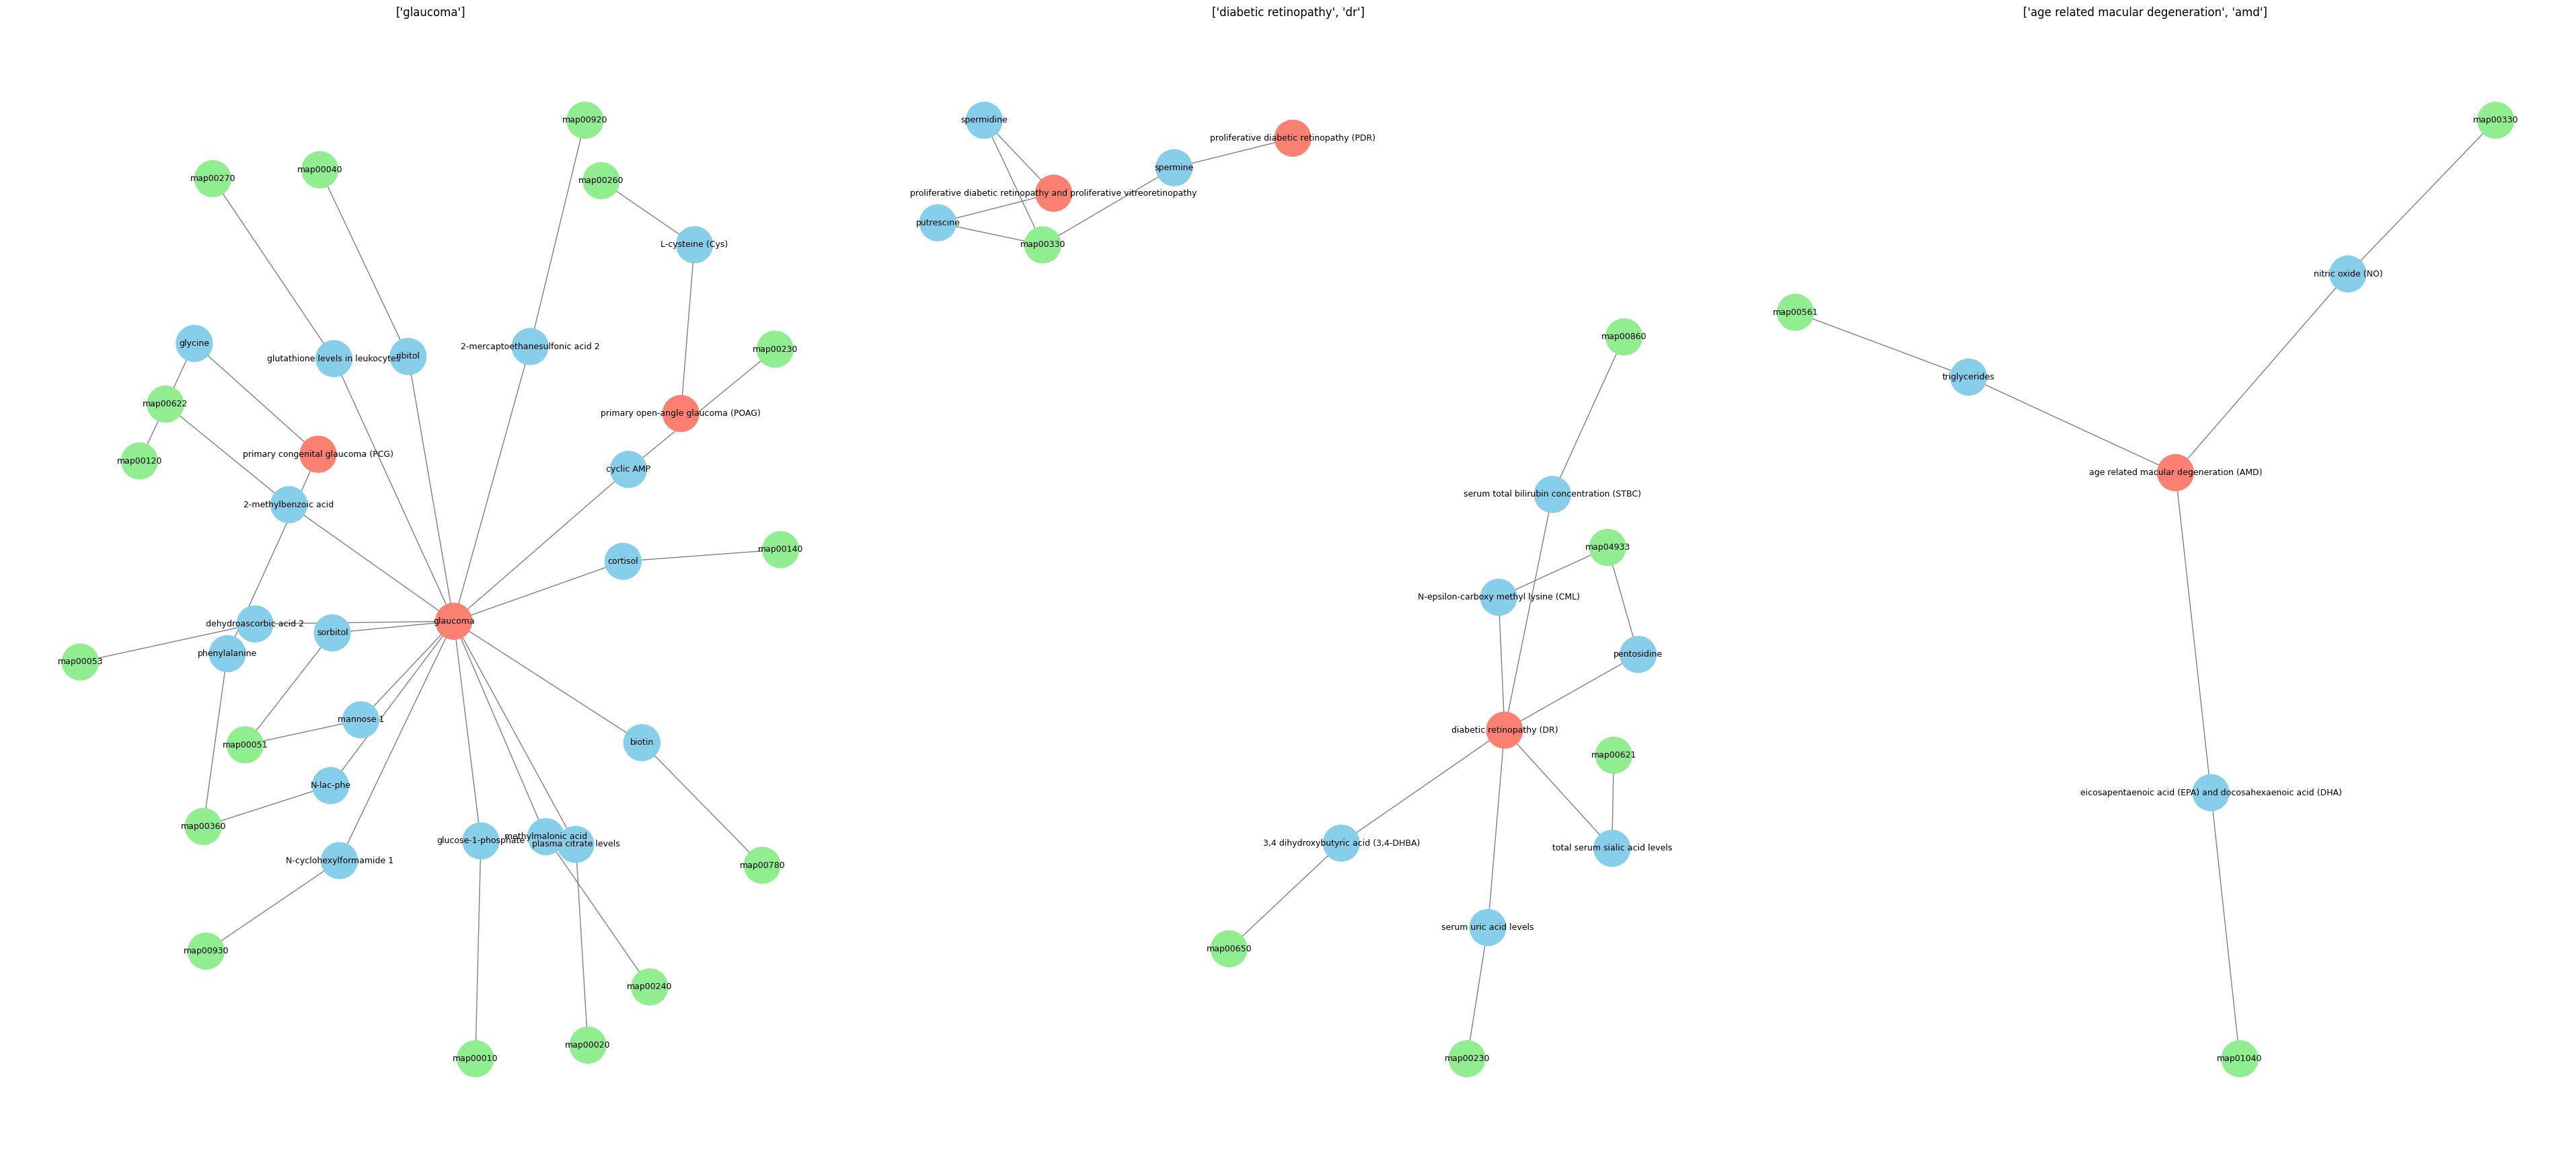

In [ ]:
# Tek figür, 1 satır 3 sütun
fig, axs = plt.subplots(1, 3, figsize=(24, 12))


for i, (keyword, title) in enumerate(diseases.items()):
    ax = axs[i]

    # Hastalığa ait satırları filtrele (küçük harfe çevir, varsa substring)
    df_disease = df_merged[df_merged['disease'].str.contains(keyword, case=False, na=False)]
    if df_disease.empty:
        ax.set_title(f"{title}\nVeri yok")
        ax.axis('off')
        continue

    # Network graph oluştur
    G = nx.Graph()

    for _, row in df_disease.iterrows():
        biomarker = row['Biomarker']
        disease = row['disease']
        pathway_id = row['Pathway_ID']
        pathway_name = row['Pathway_Name']

        # Düğümler
        G.add_node(biomarker, type='biomarker')
        G.add_node(disease, type='disease')
        G.add_node(pathway_id, type='pathway', label=pathway_name)

        # Kenarlar
        G.add_edge(biomarker, disease)
        G.add_edge(biomarker, pathway_id)

    # Node renklerini belirle
    color_map = []
    for node in G.nodes(data=True):
        ntype = node[1].get('type', '')
        if ntype == 'biomarker':
            color_map.append('skyblue')
        elif ntype == 'disease':
            color_map.append('salmon')
        elif ntype == 'pathway':
            color_map.append('lightgreen')
        else:
            color_map.append('grey')

    # Layout
    pos = nx.spring_layout(G, seed=42, k=0.5)

    # Grafik çizimi - Küre boyutunu artır ve fontu büyüt
    nx.draw(G, pos, ax=ax, node_color=color_map, with_labels=True, font_size=9,
            node_size=1500, edge_color='gray')
    ax.set_title(title)
    # Eksenleri kapat
    ax.axis('off')
plt.tight_layout(rect=[0, 0, 1.6, 1.45])
plt.show()


In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

mols = [Chem.MolFromSmiles(s) for s in df_merged['Smiles']]

fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in mols]

# Örnek: Tanimoto benzerliği matrisi
similarity_matrix = []
for i in range(len(fps)):
    row = []
    for j in range(len(fps)):
        sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
        row.append(sim)
    similarity_matrix.append(row)

[11:09:40] DEPRECATION WARNING: please use MorganGenerator
[11:09:40] DEPRECATION WARNING: please use MorganGenerator
[11:09:40] DEPRECATION WARNING: please use MorganGenerator
[11:09:40] DEPRECATION WARNING: please use MorganGenerator
[11:09:40] DEPRECATION WARNING: please use MorganGenerator
[11:09:40] DEPRECATION WARNING: please use MorganGenerator
[11:09:40] DEPRECATION WARNING: please use MorganGenerator
[11:09:40] DEPRECATION WARNING: please use MorganGenerator
[11:09:40] DEPRECATION WARNING: please use MorganGenerator
[11:09:40] DEPRECATION WARNING: please use MorganGenerator
[11:09:40] DEPRECATION WARNING: please use MorganGenerator
[11:09:40] DEPRECATION WARNING: please use MorganGenerator
[11:09:40] DEPRECATION WARNING: please use MorganGenerator
[11:09:40] DEPRECATION WARNING: please use MorganGenerator
[11:09:40] DEPRECATION WARNING: please use MorganGenerator
[11:09:40] DEPRECATION WARNING: please use MorganGenerator
[11:09:40] DEPRECATION WARNING: please use MorganGenerat

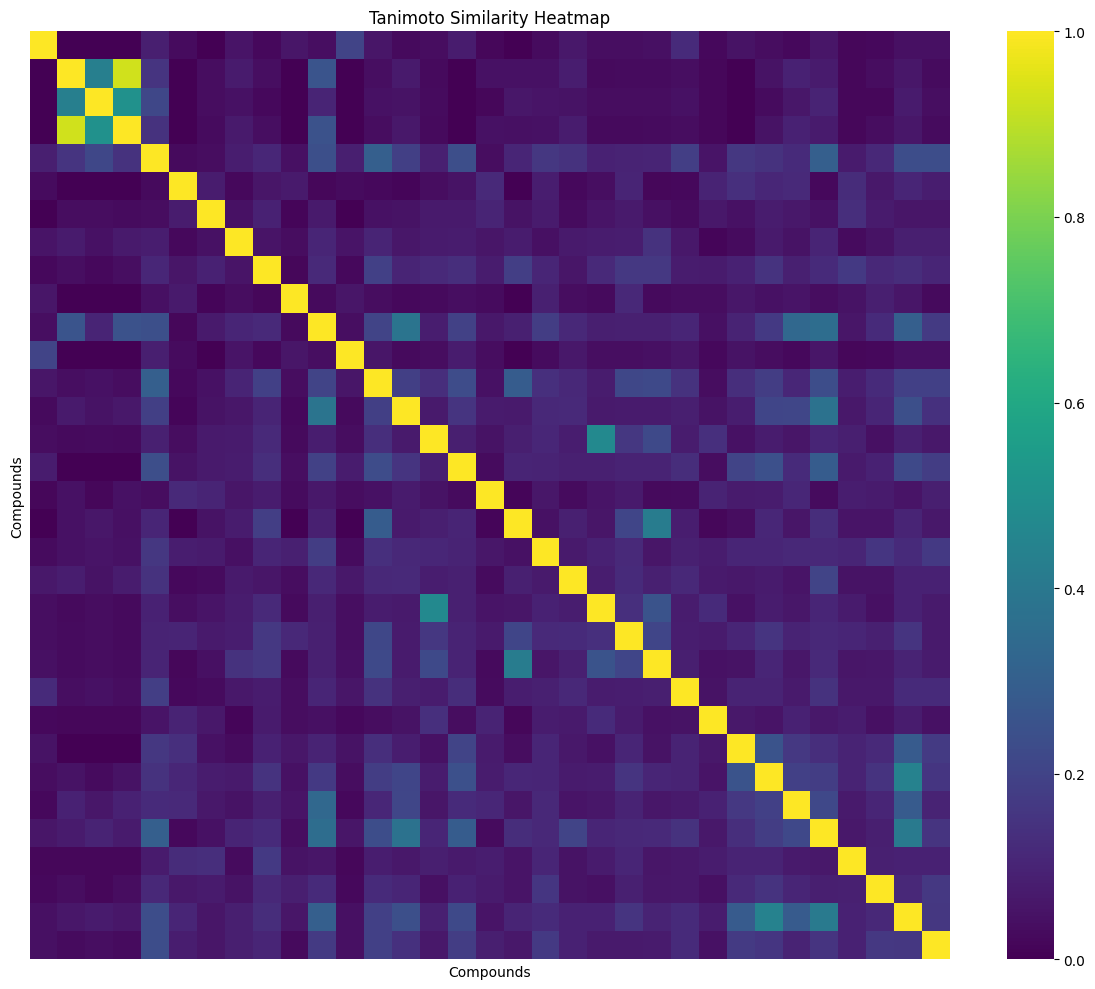

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Matris -> NumPy array'e çevir
sim_array = np.array(similarity_matrix)

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(sim_array, cmap='viridis', xticklabels=False, yticklabels=False)
plt.title("Tanimoto Similarity Heatmap")
plt.xlabel("Compounds")
plt.ylabel("Compounds")
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/cluster/_agglomerative.py:588: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  out = hierarchy.linkage(X, method=linkage, metric=affinity)
/tmp/ipython-input-861045429.py:22: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linked = linkage(distance_matrix, 'average')


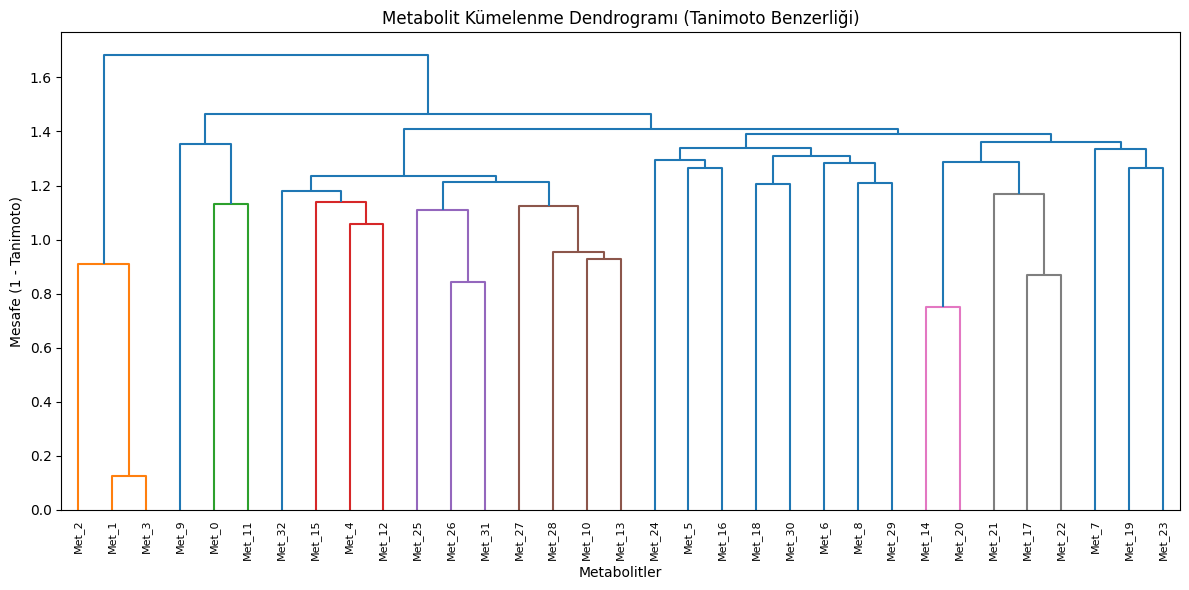

In [ ]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage

# similarity_matrix = ...  # Sizin oluşturduğunuz Tanimoto benzerlik matrisi
# Örnek: NumPy dizisine çevirin
sim_matrix = np.array(similarity_matrix)

# Mesafeye çevir (Tanimoto similarity → distance)
distance_matrix = 1 - sim_matrix

# Kümelenme (hiyerarşik)
clustering = AgglomerativeClustering( linkage='average')
labels = clustering.fit_predict(distance_matrix)

# Görselleştirme: Dendrogram
linked = linkage(distance_matrix, 'average')
plt.figure(figsize=(12, 6))
dendrogram(linked, labels=[f"Met_{i}" for i in range(len(sim_matrix))], leaf_rotation=90)
plt.title("Metabolit Kümelenme Dendrogramı (Tanimoto Benzerliği)")
plt.xlabel("Metabolitler")
plt.ylabel("Mesafe (1 - Tanimoto)")
plt.tight_layout()
plt.show()


In [ ]:
#Cataract için özel olan metabolitler neler?
# 1. Sadece metabolitleri filtrele
metabolite_df = df_merged[df_merged['Category4'] == 'Metabolite']

# 2. Her bir biomarker'ın geçtiği hastalıkları say
biomarker_disease_map = metabolite_df.groupby('Biomarker')['disease'].nunique()

# 3. Sadece 1 hastalıkta geçenleri al (yani spesifik olanlar)
specific_biomarkers = biomarker_disease_map[biomarker_disease_map == 1].index.tolist()

# 4. Bu spesifiklerin cataract için olanlarını al
dr_specific = metabolite_df[
    (metabolite_df['disease'].str.lower().str.contains("dr")) &
    (metabolite_df['Biomarker'].isin(specific_biomarkers))
]

# Sonuçları göster
dr_specific[['Biomarker', 'Compound_ID', 'Smiles', 'disease']]


,Biomarker,Compound_ID,Smiles,disease
1,spermine,c00750,C(CCNCCCN)CNCCCN,proliferative diabetic retinopathy (PDR)
8,total serum sialic acid levels,c00805,CC(=O)N[C@H]1[C@H]([C@@H](O)[C@@H](O)CO)O[C@@]...,diabetic retinopathy (DR)
9,serum uric acid levels,c00366,C12=C(NC(=O)N1)NC(=O)NC2=O,diabetic retinopathy (DR)
10,N-epsilon-carboxy methyl lysine (CML),c21011,C(CCNCC(=O)O)C[C@@H](C(=O)O)N,diabetic retinopathy (DR)
12,"3,4 dihydroxybutyric acid (3,4-DHBA)",c01089,C([C@@H](CO)O)C(=O)O,diabetic retinopathy (DR)
27,pentosidine,c21014,C1=CN(C2=NC(=NC2=C1)NCCC[C@@H](C(=O)O)N)CCCC[C...,diabetic retinopathy (DR)
30,serum total bilirubin concentration (STBC),c00486,CC1=C(NC(=C1CCC(=O)O)CC2=C(C(=C(N2)/C=C\3/C(=C...,diabetic retinopathy (DR)


In [ ]:
len(dr_specific)

7

In [ ]:
def get_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
    return None

grouped = df_merged.groupby('Pathway_ID')
pathway_similarities = []

for pid, group in grouped:
    smiles_list = group['Smiles'].dropna().unique()
    fps = [get_fingerprint(s) for s in smiles_list if get_fingerprint(s)]

    n = len(fps)
    if n < 2:
        continue  # benzerlik hesaplanamaz

    # Tanimoto benzerlik matrisinden ortalama
    sim_sum = 0
    count = 0
    for i in range(n):
        for j in range(i+1, n):
            sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
            sim_sum += sim
            count += 1

    avg_similarity = sim_sum / count if count else 0
    pathway_name = group['Pathway_Name'].iloc[0]
    pathway_similarities.append((pid, pathway_name, avg_similarity))
similarity_df = pd.DataFrame(pathway_similarities, columns=['Pathway_ID', 'Pathway_Name', 'Avg_Tanimoto_Similarity'])
similarity_df = similarity_df.sort_values(by='Avg_Tanimoto_Similarity', ascending=False)
similarity_df.head(10)


[11:14:03] DEPRECATION WARNING: please use MorganGenerator
[11:14:03] DEPRECATION WARNING: please use MorganGenerator
[11:14:03] DEPRECATION WARNING: please use MorganGenerator
[11:14:03] DEPRECATION WARNING: please use MorganGenerator
[11:14:03] DEPRECATION WARNING: please use MorganGenerator
[11:14:03] DEPRECATION WARNING: please use MorganGenerator
[11:14:03] DEPRECATION WARNING: please use MorganGenerator
[11:14:03] DEPRECATION WARNING: please use MorganGenerator
[11:14:03] DEPRECATION WARNING: please use MorganGenerator
[11:14:03] DEPRECATION WARNING: please use MorganGenerator
[11:14:03] DEPRECATION WARNING: please use MorganGenerator
[11:14:03] DEPRECATION WARNING: please use MorganGenerator
[11:14:03] DEPRECATION WARNING: please use MorganGenerator
[11:14:03] DEPRECATION WARNING: please use MorganGenerator
[11:14:03] DEPRECATION WARNING: please use MorganGenerator
[11:14:03] DEPRECATION WARNING: please use MorganGenerator
[11:14:03] DEPRECATION WARNING: please use MorganGenerat

,Pathway_ID,Pathway_Name,Avg_Tanimoto_Similarity
3,map00360,Phenylalanine metabolism,0.444444
4,map04933,AGE-RAGE signaling pathway in diabetic complic...,0.333333
2,map00330,Arginine and proline metabolism,0.309524
0,map00051,Fructose and mannose metabolism,0.057143
1,map00230,Purine metabolism,0.031746


In [ ]:
def get_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048)
    return None

grouped = dr_specific.groupby('Pathway_ID')
pathway_similarities = []

for pid, group in grouped:
    smiles_list = group['Smiles'].dropna().unique()
    fps = [get_fingerprint(s) for s in smiles_list if get_fingerprint(s)]

    n = len(fps)
    if n < 2:
        continue  # benzerlik hesaplanamaz

    # Tanimoto benzerlik matrisinden ortalama
    sim_sum = 0
    count = 0
    for i in range(n):
        for j in range(i+1, n):
            sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
            sim_sum += sim
            count += 1

    avg_similarity = sim_sum / count if count else 0
    pathway_name = group['Pathway_Name'].iloc[0]
    pathway_similarities.append((pid, pathway_name, avg_similarity))
similarity_df = pd.DataFrame(pathway_similarities, columns=['Pathway_ID', 'Pathway_Name', 'Avg_Tanimoto_Similarity'])
similarity_df = similarity_df.sort_values(by='Avg_Tanimoto_Similarity', ascending=False)
similarity_df.head(10)


[11:13:56] DEPRECATION WARNING: please use MorganGenerator
[11:13:56] DEPRECATION WARNING: please use MorganGenerator
[11:13:56] DEPRECATION WARNING: please use MorganGenerator
[11:13:56] DEPRECATION WARNING: please use MorganGenerator
[11:13:56] DEPRECATION WARNING: please use MorganGenerator
[11:13:56] DEPRECATION WARNING: please use MorganGenerator
[11:13:56] DEPRECATION WARNING: please use MorganGenerator
[11:13:56] DEPRECATION WARNING: please use MorganGenerator
[11:13:56] DEPRECATION WARNING: please use MorganGenerator
[11:13:56] DEPRECATION WARNING: please use MorganGenerator
[11:13:56] DEPRECATION WARNING: please use MorganGenerator
[11:13:56] DEPRECATION WARNING: please use MorganGenerator
[11:13:56] DEPRECATION WARNING: please use MorganGenerator
[11:13:56] DEPRECATION WARNING: please use MorganGenerator


,Pathway_ID,Pathway_Name,Avg_Tanimoto_Similarity
0,map04933,AGE-RAGE signaling pathway in diabetic complic...,0.333333


/tmp/ipython-input-1928660070.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=similarity_df.head(10), x='Avg_Tanimoto_Similarity', y='Pathway_Name', palette='viridis')


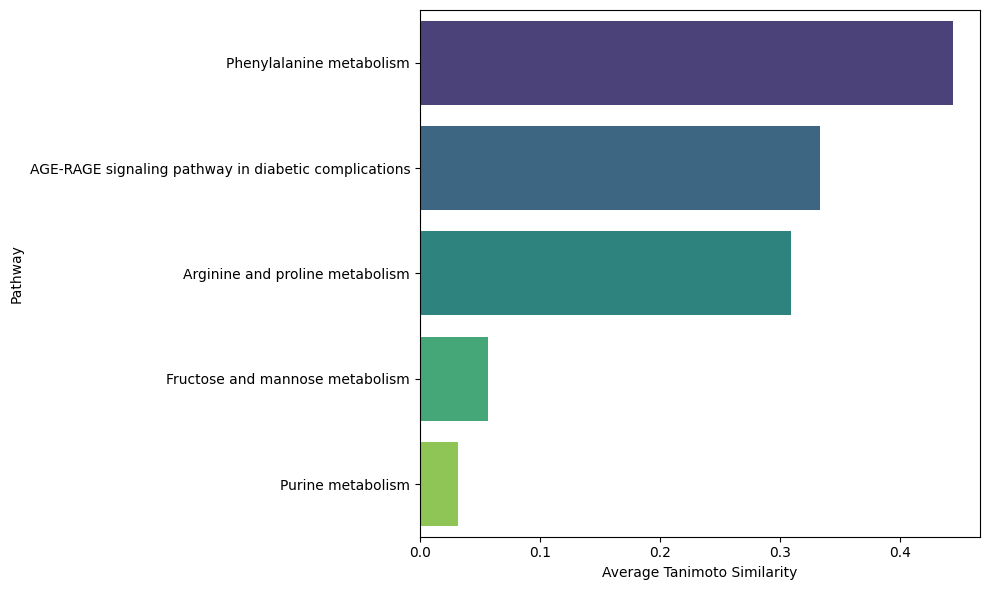

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(data=similarity_df.head(10), x='Avg_Tanimoto_Similarity', y='Pathway_Name', palette='viridis')
#plt.title("The highest 10 Pathways Metabolite Similarity ")
plt.xlabel("Average Tanimoto Similarity")
plt.ylabel("Pathway")
plt.tight_layout()
plt.savefig('Fig7-eye.png', dpi=300, format='png', bbox_inches='tight')
plt.show()
